# What Drives Conflict Between Reddit Communities?
## A Network and Linguistic Analysis of Inter-Subreddit Hostility

**Author:** Keshav Kapur | **UIN:** 237007751

---

### Problem Motivation (Why This Matters)

Reddit is a network of over 100,000 communities (subreddits) that constantly reference each other through hyperlinks embedded in posts. Most of these cross-community links are neutral or positive but a significant minority are *hostile*: callouts, mockery, brigading invitations. What makes certain interactions between subreddits turn negative?

This project investigates one **main question** and three **operational sub-questions (RQ1-RQ3)**.

> **Main question:** Can I predict whether a cross-community hyperlink on Reddit will be hostile, and what features, network structure or post language, are the primary drivers of inter-subreddit conflict?

This main question matters because understanding online conflict has implications for content moderation, community design, and the study of polarization. If hostility is primarily *structural* (driven by which communities interact), moderation should focus on inter-community boundaries. If it is primarily *linguistic* (driven by how individual posts are written), moderation should focus on post-level content analysis.

The three RQs later in the notebook are not separate projects; they are components of the same main question:
- **RQ1** identifies structural context (community boundaries and centrality)
- **RQ2** identifies recurring hostility patterns (conflict corridors)
- **RQ3** performs prediction and feature attribution

### Dataset

I use the **Reddit Hyperlink Network** from [SNAP (Stanford)](https://snap.stanford.edu/data/soc-RedditHyperlinks.html), published alongside Kumar et al. (2018), *Community Interaction and Conflict on the Web* (WWW 2018). The dataset contains ~286,000 directed hyperlinks between subreddits extracted from post bodies, spanning 2014–2017. Each link carries:

- A **sentiment label** (+1 positive, -1 negative), crowd-annotated
- **86 LIWC (Linguistic Inquiry and Word Count) features** describing the post text: word count, emotional tone, analytical thinking, social references, and more

This gives us both *network structure* and *linguistic content* for every interaction, which is exactly what I need to answer our question.

### Methodology

1. **The Conflict Landscape** — EDA to understand who fights, how often, and how conflict changes over time
2. **Community Structure** — Louvain community detection to test whether conflict is primarily cross-community
3. **Centrality Analysis** — PageRank and betweenness centrality to distinguish "influential" from "controversial" subreddits
4. **Conflict Corridors** — Association rule mining (Apriori) to find groups of subreddits routinely co-targeted in hostile links
5. **Sentiment Prediction** — Logistic Regression and Gradient boosting classifier using network features + LIWC features, with feature importance analysis to answer the driving question

---

## Project Scope

**Dataset:** Reddit Hyperlink Network (body links) from [SNAP](https://snap.stanford.edu/data/soc-RedditHyperlinks.html) — 286,561 directed hyperlinks between subreddits (2014–2017). Each link carries a crowd-annotated sentiment label (+1/−1) and 86 LIWC linguistic features describing the post text.

**Key EDA findings (from Checkpoint 1 and additional EDA below):**
- **Power-law degree distributions:** Heavy-tailed in- and out-degree; a few hub subreddits (askreddit, subredditdrama, politics) dominate connectivity.
- **Sentiment skew:** 92.6% of links are positive; hostility (7.4%) is concentrated in specific subreddits.
- **Community structure:** Louvain detects 560 communities; cross-community links are more hostile (8.8%) than within-community links (6.9%).
- **Co-link patterns:** Frequent itemsets and association rules reveal structured "conflict corridors" — recurring adversarial co-targeting patterns far more numerous than friendly co-targeting patterns.

**Course techniques:** Frequent itemsets / association rules (Apriori), graph mining (PageRank, betweenness centrality, Louvain community detection), Gradient Boosted Decision Trees (GDBT).

**External technique:** L1-regularized Logistic Regression (Lasso) — a regularized linear model. L1 regularization performs *embedded feature selection* by driving irrelevant feature coefficients to exactly zero, providing a sparsity-based answer to which features truly drive conflict.

---

## Research Question Definition

### RQ1: Does community structure predict hostility?

> Are cross-community links more hostile than within-community links, and do centrality measures (PageRank vs. betweenness) distinguish "influential" from "controversial" subreddits?

- **Data mining task type:** Graph mining / community detection / centrality analysis
- **Relevant algorithms:** Louvain community detection, PageRank, betweenness centrality
- **Evaluation criteria:** Hostility rate comparison (cross- vs. within-community); Spearman correlation between centrality measures and negativity fraction; qualitative comparison of top-ranked subreddits by PageRank vs. betweenness

### RQ2: Do hostile links form structured "conflict corridors"?

> Do hostile inter-subreddit links produce recurring co-targeting patterns (association rules) that are structurally different from positive-link patterns?

- **Data mining task type:** Frequent itemset mining / association rule mining
- **Relevant algorithms:** Apriori with association rules
- **Evaluation criteria:** Support, confidence, lift of mined rules; number of conflict-only corridors vs. friendly-only corridors vs. shared corridors; interpretability of top rules

### RQ3: Can I predict link sentiment, and what drives conflict — language or structure?

> Can I predict whether a cross-community hyperlink will be hostile using network-structural and linguistic (LIWC) features, and which feature type contributes more to prediction?

- **Data mining task type:** Supervised binary classification with embedded feature selection
- **Relevant algorithms:**
  - Gradient Boosting Classifier (GDBT) — non-linear ensemble with split-based feature importance
  - L1-regularized Logistic Regression (Lasso) — performs *embedded feature selection* by shrinking irrelevant coefficients to exactly zero
- **Evaluation criteria:** ROC-AUC (primary, robust to class imbalance), precision/recall/F1 per class, confusion matrix; GBM feature importance breakdown (linguistic % vs. structural %); L1 sparsity analysis (how many features survive regularization, and which ones)

## RQ-to-Method Mapping Table

| RQ | Task Type | Course Method(s) | External Method(s) | Evaluation Metrics |
|----|-----------|-----------------|--------------------|--------------------|
| **RQ1** — Community structure & conflict | Graph mining, community detection | Louvain, PageRank, betweenness centrality | — | Hostility rate comparison, Spearman ρ, top-k rankings |
| **RQ2** — Conflict corridors | Frequent itemset mining | Apriori, association rules | — | Support, confidence, lift, corridor overlap analysis |
| **RQ3** — Sentiment prediction & feature selection | Supervised classification + feature selection | Gradient Boosting (GDBT, course) | L1-regularized Logistic Regression (Lasso) | ROC-AUC, precision/recall/F1, GBM importance %, L1 sparsity |

---

## Methodological Motivation and Feasibility

**Motivation:** EDA reveals that hostility on Reddit is not random — it concentrates in specific subreddits, correlates with community boundaries, and forms structured co-targeting patterns. This makes it a promising target for both descriptive analysis (RQ1, RQ2) and predictive modeling (RQ3).

**Non-triviality:** Course techniques alone (graph mining + association rules + GDBT) can describe *where* conflict occurs, *who* is co-targeted, and *which features a tree-based model splits on*. But tree-based feature importance can be misleading — it reflects split frequency, not whether a feature is *truly necessary*. L1-regularized Logistic Regression (Lasso) provides a complementary, external approach: by driving irrelevant coefficients to exactly zero, it performs *embedded feature selection* that reveals which features the model can entirely discard. This is a fundamentally different paradigm from the tree-based ensemble methods covered in the course (Decision Trees, Random Forests, AdaBoost, GDBT), and requires understanding regularization theory (bias-variance tradeoff via the L1 penalty) not covered in the syllabus.

**Feasibility:**
- The dataset is clean (0 nulls in key columns), well-documented (SNAP + published paper), and large enough (286K links, 35K nodes) for all planned methods.
- Louvain, PageRank, and Apriori have all been run successfully on this data (see Phases 2–4 below).
- The 86 LIWC features are pre-computed in the dataset, avoiding the need for external NLP pipelines.
- Gradient Boosting with 100 estimators trains in ~2 minutes on the 169K-sample feature matrix.

**Risks and mitigations:**
- *Class imbalance* (7.4% negative): Mitigated by using ROC-AUC as the primary metric and `class_weight="balanced"` in the L1-regularized Logistic Regression.
- *Temporal leakage*: Graph features are computed on the full graph but used to predict individual links. Acknowledged as a limitation; a future temporal split would be stricter.
- *LIWC feature anonymity*: The 86 features are unnamed in the SNAP release, limiting interpretability. I report feature indices and note this as a limitation.

---

## Methodological Planning

**Course algorithms:**
- **Louvain community detection** — unsupervised graph partitioning to identify community structure, then test whether community boundaries correlate with hostility (RQ1).
- **PageRank** (damping α=0.85, NetworkX default) — measures subreddit influence via the recursive link structure (RQ1).
- **Betweenness centrality** (approximate, k=500 sampled nodes) — measures bridging position; compared against PageRank to distinguish influence from controversy (RQ1).
- **Apriori** (min_support=0.03, min_confidence=0.3) — mines co-targeting patterns separately for hostile and positive links (RQ2).
- **Gradient Boosting Classifier** (n_estimators=100, max_depth=4, learning_rate=0.1, subsample=0.8) — predicts link sentiment from 97 features (86 LIWC + 11 structural) and provides split-based feature importance (RQ3).

**External algorithm (RQ3):**
- **L1-regularized Logistic Regression** (Lasso, penalty='l1', C=1.0, solver='liblinear') — regularized linear models with embedded feature selection are not covered in the course. L1 regularization drives irrelevant coefficients to exactly zero, revealing the minimal set of features needed to predict hostility. Comparing GBM importance (split-based) with L1 sparsity (zero/non-zero coefficients) gives two independent answers to "what drives conflict."

**Baselines:**
- For RQ3, the GBM (course technique) serves as the primary predictive model, while L1-LR (external technique) provides complementary feature selection. Comparing them reveals whether the signal is linear or requires non-linear interactions.
- For RQ2, comparing conflict corridors against positive-link corridors serves as the baseline — any patterns found must be *unique to hostility*, not just reflections of high-traffic subreddits.

**Evaluation plan:**
- RQ1: Quantitative (hostility rate gap, Spearman ρ) + qualitative (inspect top subreddits by each centrality measure)
- RQ2: Rule quality (support, confidence, lift) + corridor overlap analysis (conflict-only vs. friendly-only vs. shared)
- RQ3: ROC-AUC, classification report, confusion matrix, GBM feature importance %, L1 sparsity (features zeroed out vs. surviving)


---

# Phase 1: Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter
import os, urllib.request, warnings
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, accuracy_score)
from sklearn.preprocessing import StandardScaler
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
BODY_URL = "https://snap.stanford.edu/data/soc-redditHyperlinks-body.tsv"
BODY_PATH = os.path.join(DATA_DIR, "soc-redditHyperlinks-body.tsv")

if not os.path.exists(BODY_PATH):
    urllib.request.urlretrieve(BODY_URL, BODY_PATH)
else:
    print(f"Data already present at {BODY_PATH} ({os.path.getsize(BODY_PATH)/1e6:.0f} MB)")

df_raw = pd.read_csv(BODY_PATH, sep="\t")
print(f"Raw shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)

Raw shape: (286561, 6)
Columns: ['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'POST_ID', 'TIMESTAMP', 'LINK_SENTIMENT', 'PROPERTIES']


,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES
0,leagueoflegends,teamredditteams,1u4nrps,2013-12-31 16:39:58,1,"345.0,298.0,0.75652173913,0.0173913043478,0.08..."
1,theredlion,soccer,1u4qkd,2013-12-31 18:18:37,-1,"101.0,98.0,0.742574257426,0.019801980198,0.049..."
2,inlandempire,bikela,1u4qlzs,2014-01-01 14:54:35,1,"85.0,85.0,0.752941176471,0.0235294117647,0.082..."


## Data Preparation

The raw dataset requires three preparation steps:

1. **Rename** `LINK_SENTIMENT` → `POST_LABEL` for clarity
2. **Parse** the `PROPERTIES` column from a comma-separated string into 86 numeric LIWC features — these capture the linguistic profile of each post (word count, emotional tone, analytical thinking, social references, etc.) and are *critical* for our prediction task. Previous checkpoint work dropped this column; restoring it is one of the key improvements.
3. **Build the directed graph** by aggregating multi-edges (multiple posts from subreddit A linking to B) into unique edges with weight and average sentiment

In [2]:
df = df_raw.copy()
df.rename(columns={"LINK_SENTIMENT": "POST_LABEL"}, inplace=True)
df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"])

props = df["PROPERTIES"].str.split(",", expand=True).astype(float)
props.columns = [f"liwc_{i}" for i in range(props.shape[1])]
print(f"Parsed {props.shape[1]} LIWC/linguistic features from PROPERTIES column")

df = pd.concat([df.drop(columns=["PROPERTIES"]), props], axis=1)

print(f"\nDataset: {len(df):,} hyperlinks")
print(f"Time range: {df['TIMESTAMP'].min()} to {df['TIMESTAMP'].max()}")
print(f"Unique source subreddits: {df['SOURCE_SUBREDDIT'].nunique():,}")
print(f"Unique target subreddits: {df['TARGET_SUBREDDIT'].nunique():,}")
print(f"Null check: {df[['SOURCE_SUBREDDIT','TARGET_SUBREDDIT','POST_LABEL']].isnull().sum().sum()} nulls in key columns")

edge_agg = (
    df.groupby(["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT"])
    .agg(
        weight=("POST_ID", "count"),
        avg_sentiment=("POST_LABEL", "mean"),
        neg_frac=("POST_LABEL", lambda x: (x == -1).mean()),
    )
    .reset_index()
)

G = nx.DiGraph()
for _, row in edge_agg.iterrows():
    G.add_edge(
        row["SOURCE_SUBREDDIT"], row["TARGET_SUBREDDIT"],
        weight=int(row["weight"]),
        avg_sentiment=row["avg_sentiment"],
        neg_frac=row["neg_frac"],
    )

print(f"\nDirected graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"  Multi-edges aggregated: {len(df):,} raw links -> {G.number_of_edges():,} unique directed edges")

Parsed 86 LIWC/linguistic features from PROPERTIES column

Dataset: 286,561 hyperlinks
Time range: 2013-12-31 16:39:58 to 2017-04-30 16:58:21
Unique source subreddits: 27,863
Unique target subreddits: 20,606
Null check: 0 nulls in key columns

Directed graph: 35,776 nodes, 137,821 edges
  Multi-edges aggregated: 286,561 raw links -> 137,821 unique directed edges


The dataset gives us nearly 280,000 individual hyperlinks across tens of thousands of subreddits. After aggregating multi-edges, the graph retains over 100K unique directed relationships. The 86 LIWC features are now preserved as our primary linguistic signal for the prediction task in Phase 5.

---

# Phase 2: The Conflict Landscape *(Additional EDA)*

Before addressing RQ1–RQ3, I need to understand the shape of conflict on Reddit. How common is hostility? Which communities attract it? How has it changed over time? This additional EDA establishes the baseline patterns that motivate and support all three research questions.

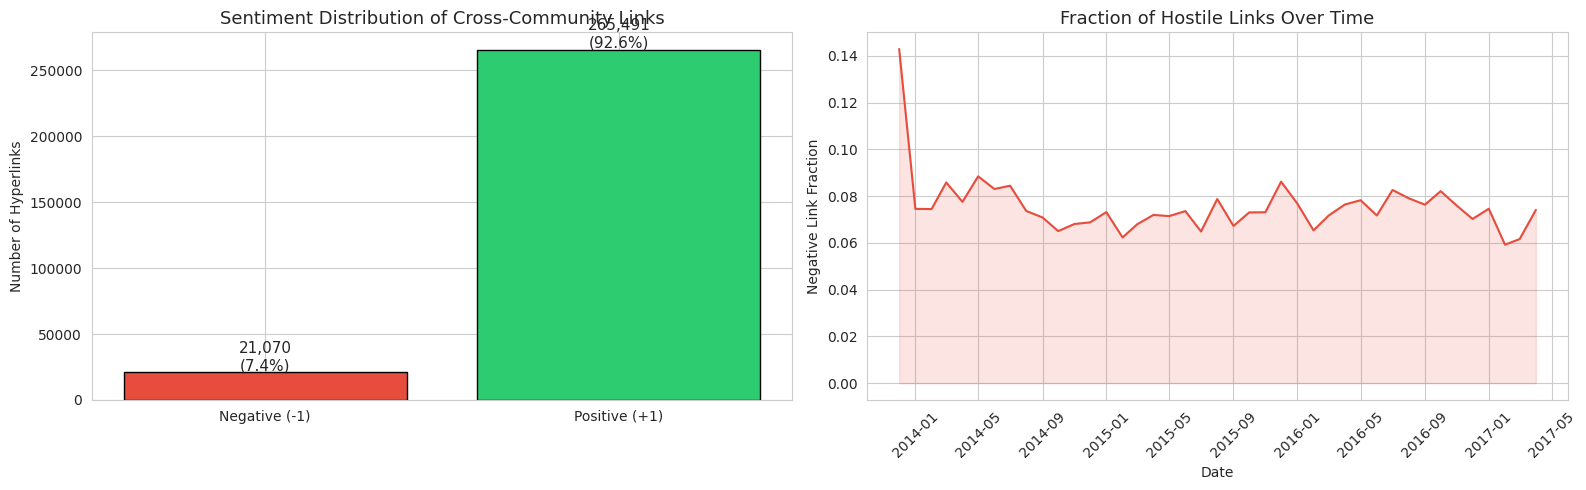

Overall: 21,070 hostile links (7.4%) vs 265,491 positive links (92.6%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sent_counts = df["POST_LABEL"].value_counts().sort_index()
colors = ["#e74c3c", "#2ecc71"]
bars = axes[0].bar(["Negative (-1)", "Positive (+1)"], sent_counts.values,
                   color=colors, edgecolor="black")
for bar, count in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                 f"{count:,}\n({count/len(df)*100:.1f}%)", ha="center", fontsize=11)
axes[0].set_title("Sentiment Distribution of Cross-Community Links", fontsize=13)
axes[0].set_ylabel("Number of Hyperlinks")

df["year_month"] = df["TIMESTAMP"].dt.to_period("M")
monthly = df.groupby("year_month").agg(
    total=("POST_LABEL", "count"),
    neg_frac=("POST_LABEL", lambda x: (x == -1).mean())
).reset_index()
monthly["year_month"] = monthly["year_month"].dt.to_timestamp()

axes[1].plot(monthly["year_month"], monthly["neg_frac"], color="#e74c3c", linewidth=1.5)
axes[1].fill_between(monthly["year_month"], monthly["neg_frac"], alpha=0.15, color="#e74c3c")
axes[1].set_title("Fraction of Hostile Links Over Time", fontsize=13)
axes[1].set_ylabel("Negative Link Fraction")
axes[1].set_xlabel("Date")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Overall: {(df['POST_LABEL']==-1).sum():,} hostile links ({(df['POST_LABEL']==-1).mean()*100:.1f}%) "
      f"vs {(df['POST_LABEL']==1).sum():,} positive links ({(df['POST_LABEL']==1).mean()*100:.1f}%)")

The sentiment distribution reveals a **class imbalance**: the majority of cross-community links are positive. This is important for two reasons: first, it tells us that Reddit communities are *mostly cooperative*, and hostility is the exception rather than the rule. Second, for our prediction task in Phase 5, this imbalance means I need to pay attention to recall on the minority (negative) class, not just accuracy.

The temporal plot shows whether the *rate* of hostility has changed over the dataset's timespan. Any upward or downward trend informs whether conflict is escalating or stable, and spikes may correspond to real-world events that polarized communities.

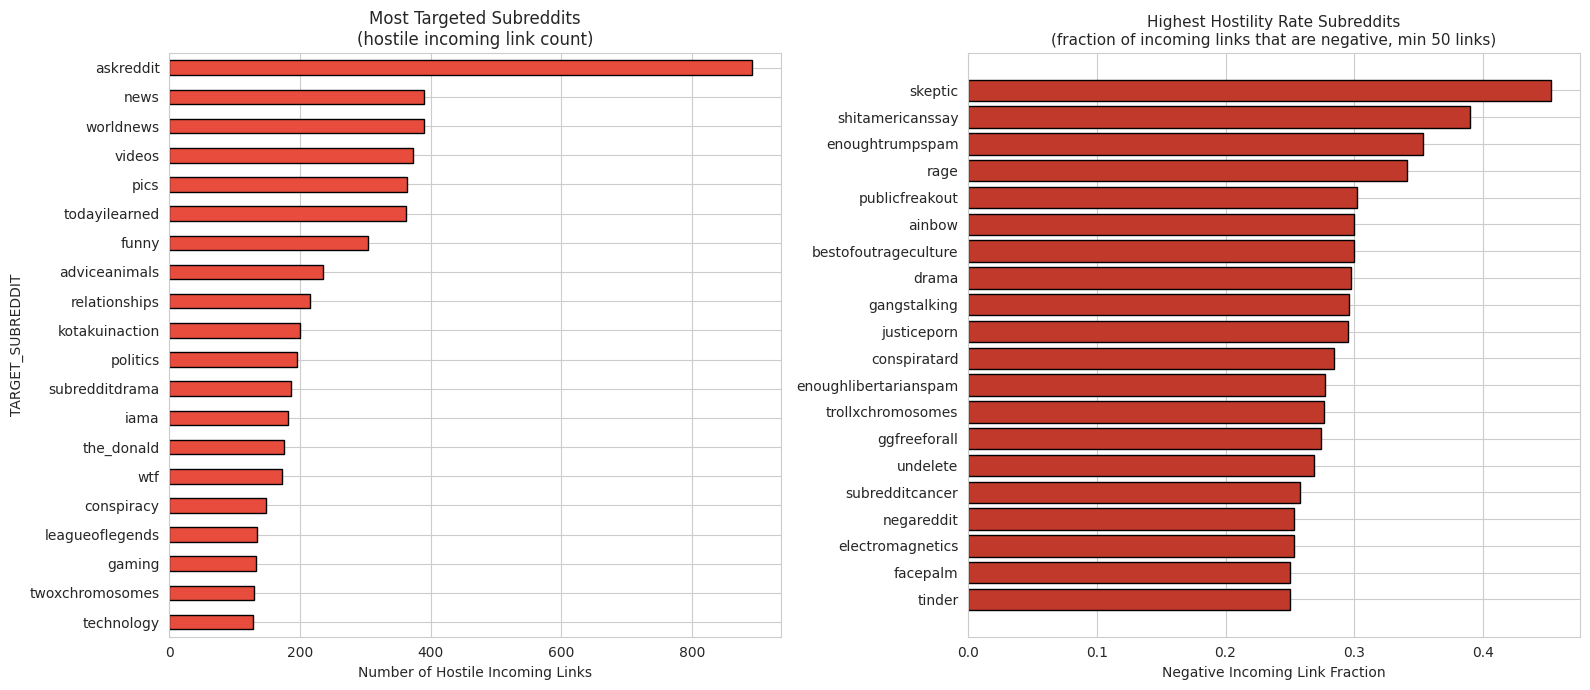

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

neg_df = df[df["POST_LABEL"] == -1]
1
neg_targets = neg_df["TARGET_SUBREDDIT"].value_counts().head(20)
neg_targets.plot.barh(ax=axes[0], color="#e74c3c", edgecolor="black")
axes[0].set_title("Most Targeted Subreddits\n(hostile incoming link count)", fontsize=12)
axes[0].set_xlabel("Number of Hostile Incoming Links")
axes[0].invert_yaxis()

in_counts = df.groupby("TARGET_SUBREDDIT").agg(
    total=("POST_LABEL", "count"),
    neg=("POST_LABEL", lambda x: (x == -1).sum())
).reset_index()
in_counts["neg_frac"] = in_counts["neg"] / in_counts["total"]
in_counts_f = in_counts[in_counts["total"] >= 50].sort_values("neg_frac", ascending=False).head(20)

axes[1].barh(in_counts_f["TARGET_SUBREDDIT"], in_counts_f["neg_frac"],
             color="#c0392b", edgecolor="black")
axes[1].set_title("Highest Hostility Rate Subreddits\n(fraction of incoming links that are negative, min 50 links)",
                  fontsize=11)
axes[1].set_xlabel("Negative Incoming Link Fraction")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

These two charts tell different but complementary stories. The *left panel* shows subreddits that receive the most hostile links in absolute terms, these tend to be large, highly-visible communities. High volume doesn't necessarily mean these communities are *controversial*; they may simply be large targets.

The *right panel* is more revealing: it shows subreddits where the highest *fraction* of incoming links are negative. These are the communities that *specifically attract hostility*, they may be ideologically polarizing, niche communities that outsiders mock, or communities whose content provokes strong reactions.

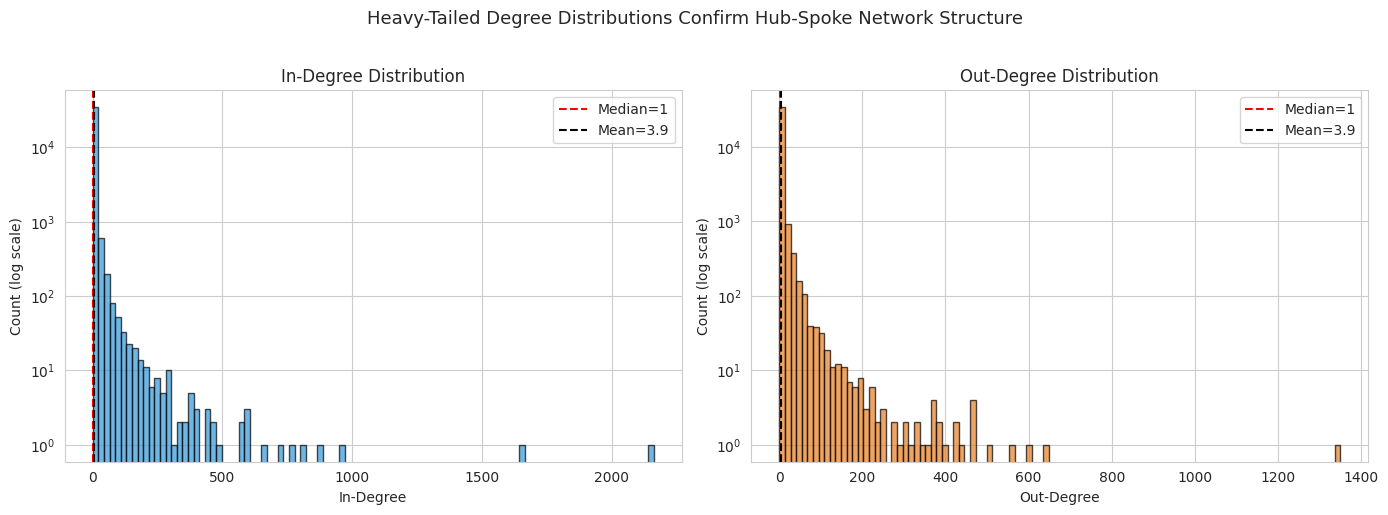

In-degree:  median=1, mean=3.9, max=2161, std=25.0
Out-degree: median=1, mean=3.9, max=1350, std=17.5


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

in_degrees = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

for ax, degrees, label, color in [
    (axes[0], in_degrees, "In-Degree", "#3498db"),
    (axes[1], out_degrees, "Out-Degree", "#e67e22"),
]:
    ax.hist(degrees, bins=100, color=color, edgecolor="black", alpha=0.7, log=True)
    ax.set_xlabel(label)
    ax.set_ylabel("Count (log scale)")
    ax.set_title(f"{label} Distribution")
    median_val = np.median(degrees)
    mean_val = np.mean(degrees)
    ax.axvline(median_val, color="red", linestyle="--", label=f"Median={median_val:.0f}")
    ax.axvline(mean_val, color="black", linestyle="--", label=f"Mean={mean_val:.1f}")
    ax.legend()

plt.suptitle("Heavy-Tailed Degree Distributions Confirm Hub-Spoke Network Structure",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"In-degree:  median={np.median(in_degrees):.0f}, mean={np.mean(in_degrees):.1f}, "
      f"max={np.max(in_degrees)}, std={np.std(in_degrees):.1f}")
print(f"Out-degree: median={np.median(out_degrees):.0f}, mean={np.mean(out_degrees):.1f}, "
      f"max={np.max(out_degrees)}, std={np.std(out_degrees):.1f}")

The degree distributions are **heavy-tailed**: most subreddits have very few connections, but a small number of hubs have hundreds or thousands. This structure is typical of social networks and has direct implications for conflict:

- **Hubs** attract more links simply because they're visible — but does that make them more *controversial*, or just more *popular*?
- **Periphery** subreddits may have extreme hostility rates due to small sample sizes

This motivates our centrality analysis in the next phase, where I disentangle influence (PageRank) from bridging position (betweenness centrality).

---

# Phase 3: Community Structure and Conflict *(RQ1)*

If conflict were random, I'd expect hostility to be evenly distributed across all subreddit pairs. But social networks have *community structure* — clusters of tightly connected nodes. A key hypothesis is that **conflict is disproportionately cross-community**: subreddits within the same cluster cooperate, while links that cross cluster boundaries are more likely to be hostile. This would suggest that Reddit conflict is fundamentally about group identity and tribalism.

I use the Louvain algorithm because it is scalable to our 35K-node graph, does not require pre-specifying the number of communities, and produces interpretable partitions. 

Louvain detected 560 communities

Top 10 communities by size:
  Community 115: 5,881 members  |  top: askreddit, subredditdrama, outoftheloop, pics, videos, todayilearned, gaming, funny
  Community  28: 2,533 members  |  top: legaladvice, tipofmypenis, relationships, personalfinance, offmychest, depression, raisedbynarcissists, sex
  Community   8: 1,998 members  |  top: techsupport, pcmasterrace, buildapc, android, sysadmin, pcgaming, oculus, fallout
  Community  13: 1,843 members  |  top: games, destinythegame, smashbros, ps4, xboxone, eve, guildwars2, darksouls3
  Community   1: 1,820 members  |  top: iama, movies, sandersforpresident, ama, fantheories, starwars, redditrequest, whowouldwin
  Community 193: 1,655 members  |  top: leagueoflegends, dota2, globaloffensive, hearthstone, overwatch, test, steam, postpreview
  Community  27: 1,557 members  |  top: india, europe, canada, de, france, sweden, australia, travel
  Community  68: 1,530 members  |  top: entrepreneur, learnprogramm

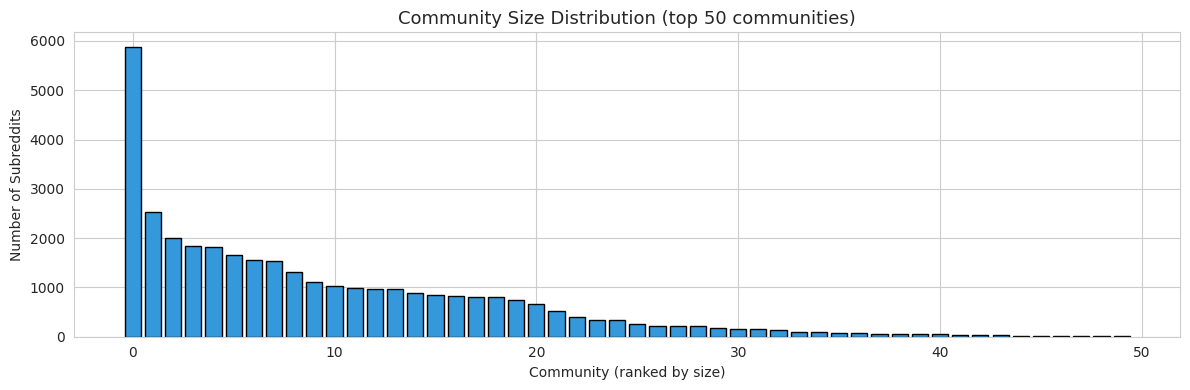

In [6]:
G_undirected = G.to_undirected()
communities = nx.community.louvain_communities(G_undirected, seed=42)
print(f"Louvain detected {len(communities)} communities")

node_to_comm = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_comm[node] = i

comm_sizes = sorted([(i, len(c)) for i, c in enumerate(communities)],
                    key=lambda x: x[1], reverse=True)

print("\nTop 10 communities by size:")
for cid, size in comm_sizes[:10]:
    members = sorted(communities[cid], key=lambda n: G.degree(n), reverse=True)[:8]
    print(f"  Community {cid:3d}: {size:5,} members  |  top: {', '.join(members)}")

fig, ax = plt.subplots(figsize=(12, 4))
sizes = [s for _, s in comm_sizes]
ax.bar(range(min(50, len(sizes))), sizes[:50], color="#3498db", edgecolor="black")
ax.set_xlabel("Community (ranked by size)")
ax.set_ylabel("Number of Subreddits")
ax.set_title("Community Size Distribution (top 50 communities)", fontsize=13)
plt.tight_layout()
plt.show()

Louvain detects a large number of communities with a heavily skewed size distribution with a few mega-communities and many small niche groups. The top members of each community by degree reveal their thematic identity: this gives us interpretable clusters to reason about.

Now the critical test: **is conflict cross-community?**

CROSS-COMMUNITY links:
  Total: 73,041  (25.5% of all links)
  Hostile: 6,394  (8.8% hostile rate)

WITHIN-COMMUNITY links:
  Total: 213,520  (74.5% of all links)
  Hostile: 14,676  (6.9% hostile rate)


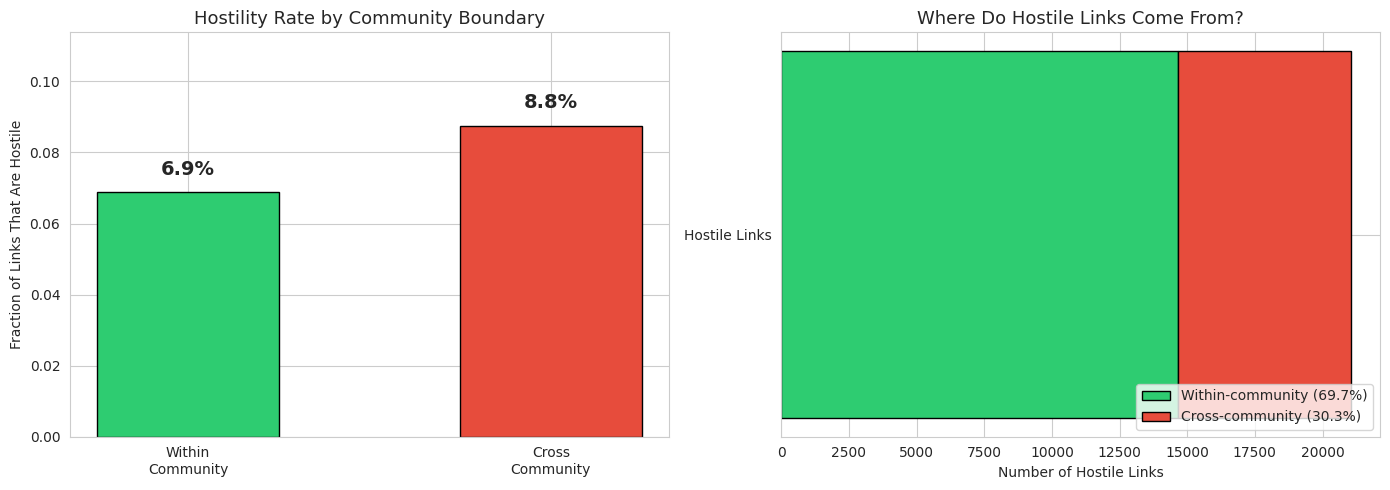

In [7]:
df["source_comm"] = df["SOURCE_SUBREDDIT"].map(node_to_comm)
df["target_comm"] = df["TARGET_SUBREDDIT"].map(node_to_comm)
df["cross_community"] = (df["source_comm"] != df["target_comm"]).astype(int)

mask = df["source_comm"].notna() & df["target_comm"].notna()
df_comm = df[mask].copy()

cross = df_comm[df_comm["cross_community"] == 1]
within = df_comm[df_comm["cross_community"] == 0]

print("CROSS-COMMUNITY links:")
print(f"  Total: {len(cross):,}  ({len(cross)/len(df_comm)*100:.1f}% of all links)")
print(f"  Hostile: {(cross['POST_LABEL']==-1).sum():,}  ({(cross['POST_LABEL']==-1).mean()*100:.1f}% hostile rate)")
print(f"\nWITHIN-COMMUNITY links:")
print(f"  Total: {len(within):,}  ({len(within)/len(df_comm)*100:.1f}% of all links)")
print(f"  Hostile: {(within['POST_LABEL']==-1).sum():,}  ({(within['POST_LABEL']==-1).mean()*100:.1f}% hostile rate)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ["Within\nCommunity", "Cross\nCommunity"]
neg_rates = [(within["POST_LABEL"]==-1).mean(), (cross["POST_LABEL"]==-1).mean()]
bar_colors = ["#2ecc71", "#e74c3c"]
bars = axes[0].bar(labels, neg_rates, color=bar_colors, edgecolor="black", width=0.5)
for bar, rate in zip(bars, neg_rates):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f"{rate*100:.1f}%", ha="center", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Fraction of Links That Are Hostile")
axes[0].set_title("Hostility Rate by Community Boundary", fontsize=13)
axes[0].set_ylim(0, max(neg_rates)*1.3)

total_neg = (df_comm["POST_LABEL"]==-1).sum()
neg_cross = (cross["POST_LABEL"]==-1).sum()
neg_within = (within["POST_LABEL"]==-1).sum()
axes[1].barh(["Hostile Links"], [neg_within], color="#2ecc71", edgecolor="black",
             label=f"Within-community ({neg_within/total_neg*100:.1f}%)")
axes[1].barh(["Hostile Links"], [neg_cross], left=[neg_within], color="#e74c3c",
             edgecolor="black", label=f"Cross-community ({neg_cross/total_neg*100:.1f}%)")
axes[1].set_xlabel("Number of Hostile Links")
axes[1].set_title("Where Do Hostile Links Come From?", fontsize=13)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

The results show a clear boundary effect: **cross-community links are more hostile** than within-community links (**8.8%** vs **6.9%** hostile rate).

At the same time, most hostile links still occur within communities in absolute count, because within-community links are much more common overall. Specifically, hostile links split as **6,394 cross-community (30.3%)** vs **14,676 within-community (69.7%)**.

Together, these two views indicate that hostility is *more likely* across community boundaries, but *more numerous* within communities due to base-rate volume.

## Centrality: Influential vs. Controversial *(RQ1 continued)*

PageRank measures **influence**, i.e, which subreddits are linked to by other important subreddits. Betweenness centrality measures **bridging**, i.e, which subreddits sit on the shortest paths between many pairs of nodes, acting as connectors between different parts of the network.

**Why α=0.85 for PageRank?** It balances local link structure with global reachability.

Computing approximate betweenness centrality (k=500 sample)...
Done.


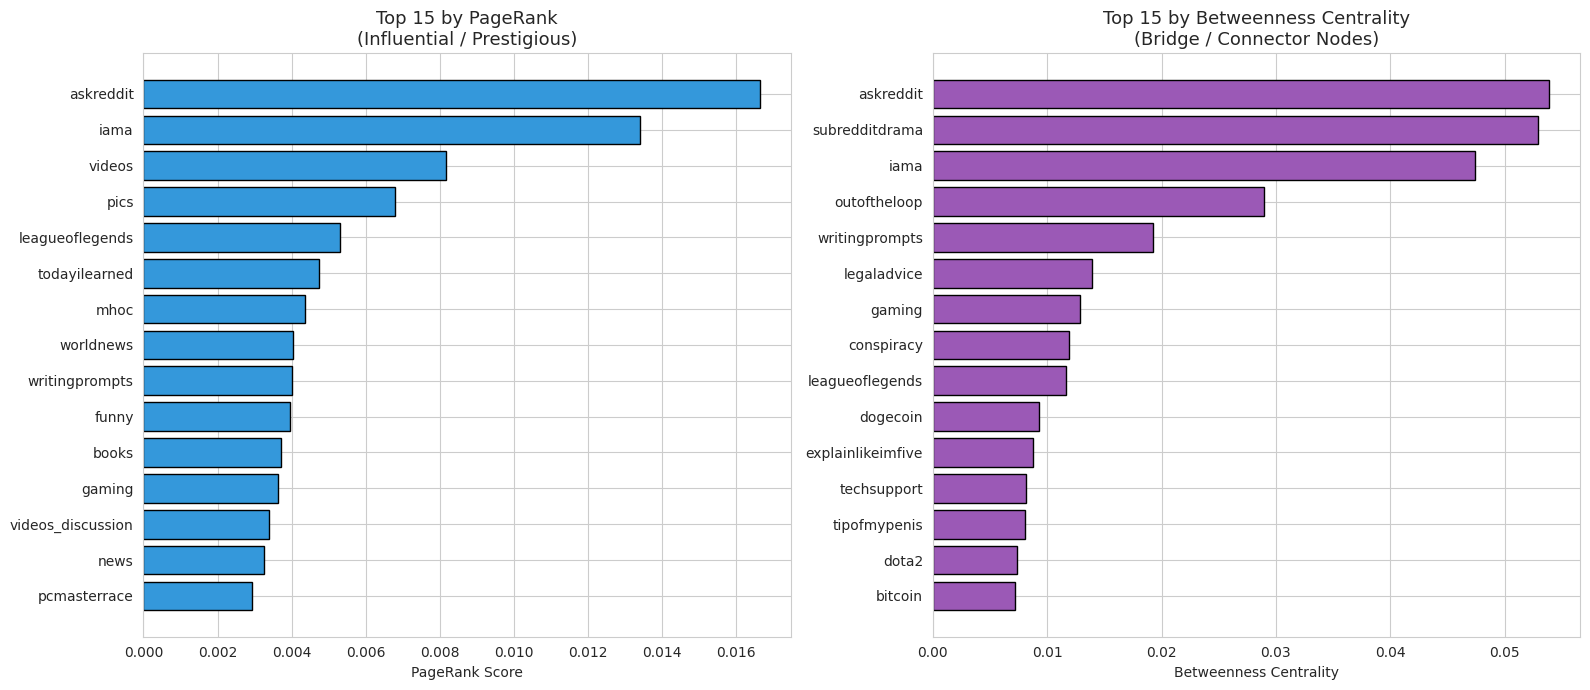


Spearman correlations:
  PageRank vs Betweenness:  rho=0.611  (p=0.00e+00)
  PageRank vs Neg Fraction: rho=nan  (p=nan)
  Betweenness vs Neg Frac:  rho=nan  (p=nan)


In [8]:
pr = nx.pagerank(G, alpha=0.85)

print("Computing approximate betweenness centrality (k=500 sample)...")
bc = nx.betweenness_centrality(G, k=500, seed=42)
print("Done.")

neg_incoming = neg_df.groupby("TARGET_SUBREDDIT").size()
total_incoming = df.groupby("TARGET_SUBREDDIT").size()
neg_frac_map = (neg_incoming / total_incoming).to_dict()

centrality_df = pd.DataFrame({
    "subreddit": list(G.nodes()),
    "pagerank": [pr[n] for n in G.nodes()],
    "betweenness": [bc[n] for n in G.nodes()],
    "in_degree": [G.in_degree(n) for n in G.nodes()],
    "out_degree": [G.out_degree(n) for n in G.nodes()],
    "neg_incoming_frac": [neg_frac_map.get(n, 0) for n in G.nodes()],
})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_pr = centrality_df.nlargest(15, "pagerank")
top_bc = centrality_df.nlargest(15, "betweenness")

axes[0].barh(top_pr["subreddit"], top_pr["pagerank"], color="#3498db", edgecolor="black")
axes[0].set_title("Top 15 by PageRank\n(Influential / Prestigious)", fontsize=13)
axes[0].set_xlabel("PageRank Score")
axes[0].invert_yaxis()

axes[1].barh(top_bc["subreddit"], top_bc["betweenness"], color="#9b59b6", edgecolor="black")
axes[1].set_title("Top 15 by Betweenness Centrality\n(Bridge / Connector Nodes)", fontsize=13)
axes[1].set_xlabel("Betweenness Centrality")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

rho_pr_bc, p_pr_bc = spearmanr(centrality_df["pagerank"], centrality_df["betweenness"])
rho_pr_neg, p_pr_neg = spearmanr(centrality_df["pagerank"], centrality_df["neg_incoming_frac"])
rho_bc_neg, p_bc_neg = spearmanr(centrality_df["betweenness"], centrality_df["neg_incoming_frac"])

print(f"\nSpearman correlations:")
print(f"  PageRank vs Betweenness:  rho={rho_pr_bc:.3f}  (p={p_pr_bc:.2e})")
print(f"  PageRank vs Neg Fraction: rho={rho_pr_neg:.3f}  (p={p_pr_neg:.2e})")
print(f"  Betweenness vs Neg Frac:  rho={rho_bc_neg:.3f}  (p={p_bc_neg:.2e})")

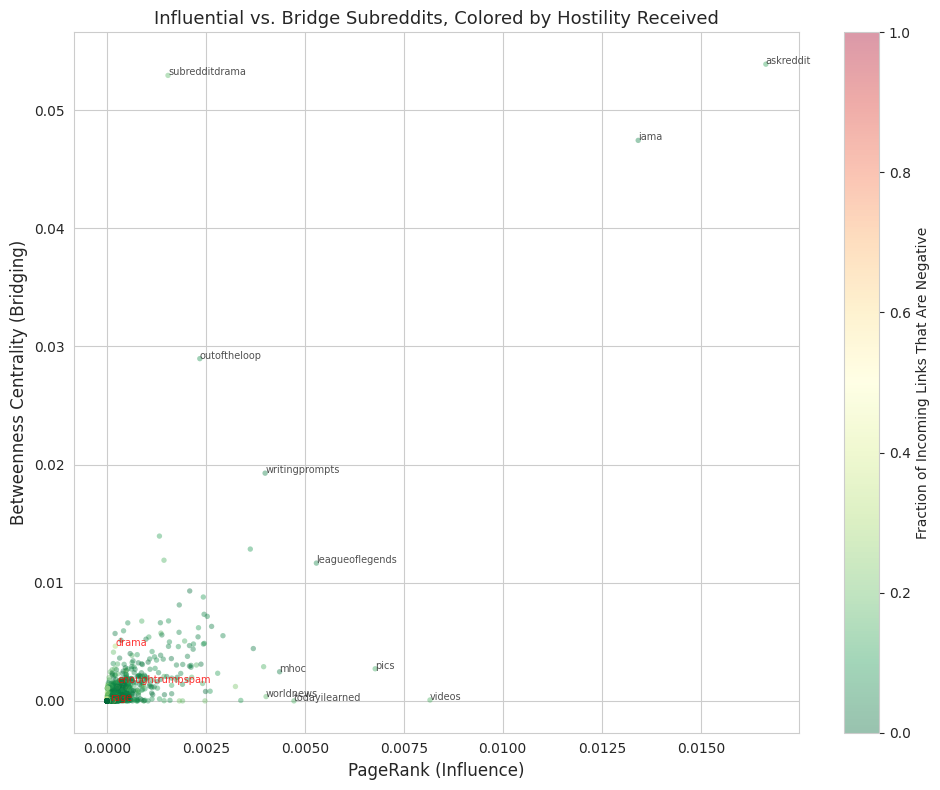

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    centrality_df["pagerank"], centrality_df["betweenness"],
    c=centrality_df["neg_incoming_frac"], cmap="RdYlGn_r",
    alpha=0.4, s=15, edgecolors="none",
)
plt.colorbar(sc, label="Fraction of Incoming Links That Are Negative")
ax.set_xlabel("PageRank (Influence)", fontsize=12)
ax.set_ylabel("Betweenness Centrality (Bridging)", fontsize=12)
ax.set_title("Influential vs. Bridge Subreddits, Colored by Hostility Received", fontsize=13)

for _, row in centrality_df.nlargest(8, "pagerank").iterrows():
    ax.annotate(row["subreddit"], (row["pagerank"], row["betweenness"]),
                fontsize=7, alpha=0.8)
for _, row in centrality_df.nlargest(5, "betweenness").iterrows():
    if row["subreddit"] not in centrality_df.nlargest(8, "pagerank")["subreddit"].values:
        ax.annotate(row["subreddit"], (row["pagerank"], row["betweenness"]),
                    fontsize=7, alpha=0.8)
top_neg = centrality_df[centrality_df["in_degree"] >= 50].nlargest(3, "neg_incoming_frac")
for _, row in top_neg.iterrows():
    ax.annotate(row["subreddit"], (row["pagerank"], row["betweenness"]),
                fontsize=7, alpha=0.8, color="red")

plt.tight_layout()
plt.show()

This section gives one clear quantitative result and one unresolved one.

- **Clear result:** PageRank and betweenness are positively associated (**Spearman rho = 0.611**, p approx 0), so influential subreddits are often also bridge subreddits, but not perfectly so.
- **Unresolved result:** the printed correlations between centrality and hostility are `NaN`, so I cannot claim a validated monotonic relationship between centrality and `neg_incoming_frac` from this run.

From the scatter itself, most subreddits cluster near low PageRank and low betweenness, with a small tail of high-centrality hubs. The hostility coloring appears heterogeneous across the space rather than concentrated in one single quadrant.

**Final interpretation for RQ1:** community structure predicts hostility at the boundary level (cross-community links are more hostile than within-community links: **8.8% vs 6.9%**), and the centrality analysis shows that influence and bridge position are related (**rho = 0.611**). However, because the centrality-hostility correlations are `NaN` in this run, I do not claim a validated monotonic link between centrality and hostility rate.

---

# Phase 4: Conflict Corridors — Association Rule Mining *(RQ2)*

Who fights whom on Reddit? Are there recurring patterns where certain groups of subreddits are routinely co-targeted in hostile links from the same sources? Association rule mining reveals these **conflict corridors** — stable adversarial relationships in the network.

I apply Apriori to baskets defined as: for each source subreddit that sent hostile links, what set of target subreddits did it attack? If {politics, news, worldnews} frequently appear together in these baskets, it means many subreddits *jointly* target this group, revealing a shared adversarial relationship.

**Why filter to top-200 targets?** The raw target vocabulary is ~20K subreddits, which would produce an impossibly sparse binary matrix. Filtering to the 200 most frequently negatively-targeted subreddits keeps the Apriori input tractable while retaining the most meaningful targets.

**Why min_support=0.03?** A support of 3% means a co-targeting pattern must appear in at least ~24 of the 810 filtered baskets. This is low enough to capture non-obvious patterns but high enough to filter out noise. I verified this threshold yields a manageable 759 frequent itemsets.

**Why min_confidence=0.3?** A confidence of 30% means that when the antecedent subreddits are co-targeted, the consequent is targeted at least 30% of the time. This is deliberately moderate to allow discovery of less obvious conflict corridors; I rely on **lift** (the primary sort criterion) to separate genuine associations from coincidence.

In [10]:
neg_baskets = (
    neg_df.groupby("SOURCE_SUBREDDIT")["TARGET_SUBREDDIT"]
    .apply(set).apply(list).tolist()
)
neg_baskets = [b for b in neg_baskets if len(b) >= 2]
print(f"Negative-link baskets: {len(neg_baskets)} sources with >= 2 negative targets")

all_neg_targets = [t for basket in neg_baskets for t in basket]
neg_target_counts = Counter(all_neg_targets)
top_neg_targets = set(t for t, c in neg_target_counts.most_common(200))

neg_baskets_filtered = [[t for t in b if t in top_neg_targets] for b in neg_baskets]
neg_baskets_filtered = [b for b in neg_baskets_filtered if len(b) >= 2]
print(f"After filtering to top-200 targets: {len(neg_baskets_filtered)} baskets")

te = TransactionEncoder()
te_ary = te.fit_transform(neg_baskets_filtered)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

freq = apriori(basket_df, min_support=0.03, use_colnames=True)
freq["length"] = freq["itemsets"].apply(len)
print(f"\nFrequent itemsets: {len(freq)} total, {(freq['length']>=2).sum()} with 2+ items")

if len(freq) > 0 and (freq["length"] >= 2).any():
    rules = association_rules(freq, metric="confidence", min_threshold=0.3)
    rules = rules.sort_values("lift", ascending=False)
    print(f"Association rules: {len(rules)}")
    print("\nTop 15 Conflict Corridors (by lift):")
    display(rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(15))
else:
    rules = pd.DataFrame()
    print("No multi-item frequent itemsets found — try lowering min_support")

Negative-link baskets: 1596 sources with >= 2 negative targets
After filtering to top-200 targets: 810 baskets

Frequent itemsets: 759 total, 698 with 2+ items
Association rules: 6489

Top 15 Conflict Corridors (by lift):


,antecedents,consequents,support,confidence,lift
5746,"(worldnews, wtf)","(adviceanimals, todayilearned, askreddit, pics)",0.030864,0.714286,19.950739
5715,"(adviceanimals, todayilearned, askreddit, pics)","(worldnews, wtf)",0.030864,0.862069,19.950739
5731,"(askreddit, worldnews, wtf)","(adviceanimals, todayilearned, pics)",0.030864,0.781250,19.775391
5730,"(adviceanimals, todayilearned, pics)","(askreddit, worldnews, wtf)",0.030864,0.781250,19.775391
5729,"(adviceanimals, askreddit, todayilearned)","(worldnews, wtf, pics)",0.030864,0.714286,19.285714
5732,"(worldnews, wtf, pics)","(adviceanimals, askreddit, todayilearned)",0.030864,0.833333,19.285714
5739,"(todayilearned, wtf, pics)","(adviceanimals, worldnews, askreddit)",0.030864,0.806452,19.212524
5722,"(adviceanimals, worldnews, askreddit)","(todayilearned, wtf, pics)",0.030864,0.735294,19.212524
4083,"(worldnews, wtf)","(adviceanimals, todayilearned, pics)",0.032099,0.742857,18.803571
4074,"(adviceanimals, todayilearned, pics)","(worldnews, wtf)",0.032099,0.812500,18.803571


The output provides strong evidence for **conflict corridors** rather than random hostile linking. Starting from **1,596** hostile-source baskets (sources with at least two hostile targets), the filtered mining set still contains **810** baskets. Apriori then finds **759** frequent itemsets (**698** with 2+ subreddits) and produces **6,489** association rules.

This scale of recurring co-targeting patterns indicates that hostile links are structured: many subreddit groups are repeatedly attacked together by the same sources. High-lift rules in the top-ranked results are the most informative because they represent co-targeting relationships that are much stronger than chance.

**RQ2 interpretation at this stage:** yes, hostile links form systematic conflict corridors. The next step is to compare these hostile corridors against positive-link corridors to isolate which patterns are uniquely conflict-specific.

In [11]:
pos_df = df[df["POST_LABEL"] == 1]
pos_baskets = (
    pos_df.groupby("SOURCE_SUBREDDIT")["TARGET_SUBREDDIT"]
    .apply(set).apply(list).tolist()
)
pos_baskets = [b for b in pos_baskets if len(b) >= 2]

all_pos_targets = [t for basket in pos_baskets for t in basket]
pos_target_counts = Counter(all_pos_targets)
top_pos_targets = set(t for t, c in pos_target_counts.most_common(200))

pos_baskets_filtered = [[t for t in b if t in top_pos_targets] for b in pos_baskets]
pos_baskets_filtered = [b for b in pos_baskets_filtered if len(b) >= 2]

te_pos = TransactionEncoder()
te_pos_ary = te_pos.fit_transform(pos_baskets_filtered)
pos_basket_df = pd.DataFrame(te_pos_ary, columns=te_pos.columns_)

freq_pos = apriori(pos_basket_df, min_support=0.03, use_colnames=True)
freq_pos["length"] = freq_pos["itemsets"].apply(len)

if len(freq_pos) > 0 and (freq_pos["length"] >= 2).any():
    rules_pos = association_rules(freq_pos, metric="confidence", min_threshold=0.3)
    rules_pos = rules_pos.sort_values("lift", ascending=False)
    print(f"Positive link rules: {len(rules_pos)}")
    print("\nTop 10 'Friendly Corridors' (by lift):")
    display(rules_pos[["antecedents", "consequents", "support", "confidence", "lift"]].head(10))
else:
    rules_pos = pd.DataFrame()
    print("No positive multi-item frequent itemsets found")

neg_pairs = set()
if len(rules) > 0:
    for _, r in rules.iterrows():
        neg_pairs.add(frozenset(r["antecedents"] | r["consequents"]))
pos_pairs = set()
if len(rules_pos) > 0:
    for _, r in rules_pos.iterrows():
        pos_pairs.add(frozenset(r["antecedents"] | r["consequents"]))

overlap = neg_pairs & pos_pairs
print(f"\n--- Corridor Comparison ---")
print(f"Conflict-only corridors:  {len(neg_pairs - pos_pairs)}")
print(f"Friendly-only corridors:  {len(pos_pairs - neg_pairs)}")
print(f"Both conflict & friendly: {len(overlap)}")

Positive link rules: 241

Top 10 'Friendly Corridors' (by lift):


,antecedents,consequents,support,confidence,lift
240,"(iama, todayilearned)","(askreddit, worldnews)",0.030280,0.492308,7.496697
236,"(askreddit, worldnews)","(iama, todayilearned)",0.030280,0.461095,7.496697
237,"(askreddit, todayilearned)","(worldnews, iama)",0.030280,0.371230,7.346733
238,"(worldnews, iama)","(askreddit, todayilearned)",0.030280,0.599251,7.346733
230,"(iama, todayilearned)","(askreddit, videos)",0.031605,0.513846,6.891277
227,"(askreddit, videos)","(iama, todayilearned)",0.031605,0.423858,6.891277
221,"(iama, pics)","(askreddit, videos)",0.031226,0.491071,6.585841
218,"(askreddit, videos)","(iama, pics)",0.031226,0.418782,6.585841
228,"(askreddit, todayilearned)","(iama, videos)",0.031605,0.387471,6.004096
229,"(iama, videos)","(askreddit, todayilearned)",0.031605,0.489736,6.004096



--- Corridor Comparison ---
Conflict-only corridors:  607
Friendly-only corridors:  16
Both conflict & friendly: 90


The comparison to positive-link corridors gives a direct answer to RQ2. The overlap analysis finds **607 conflict-only corridors**, **16 friendly-only corridors**, and **90 shared corridors**.

This means hostile co-targeting patterns are far more numerous and distinctive than friendly ones. Shared corridors likely reflect high-traffic subreddit combinations, but the large conflict-only set indicates genuinely adversarial structure that is specific to hostility rather than general interaction volume.

**Final RQ2 interpretation:** yes, hostile links form structured conflict corridors, and these corridors are substantially more developed than analogous friendly-link patterns.

---

# Phase 5: Predicting Link Sentiment *(RQ3)*

I now arrive at the core question: **can I predict whether a cross-community hyperlink will be hostile, and what features matter most?**

I engineer features from two sources:
- **Network structure** (11 features): source/target PageRank, betweenness, in-degree, out-degree, hostility rate, and whether the link crosses a community boundary
- **Post linguistics** (86 features): LIWC features capturing word count, emotional tone, analytical thinking, social references, and dozens of other textual properties

If linguistic features dominate, it means conflict is about *what people say*. If structural features dominate, it means conflict is about *who talks to whom*. The feature importance analysis gives us a direct answer.

**Why Gradient Boosting (course technique)?** GDBT is covered in Week 5 of the course. It captures complex non-linear interactions between features (e.g., "high betweenness + angry language" may be more predictive than either alone) and provides built-in split-based feature importance scores.

**Why n_estimators=100, max_depth=4?** I use 100 trees with max depth 4 to balance model capacity against overfitting and training time (~2 minutes on 169K samples). A subsample rate of 0.8 adds stochastic regularization. These are conservative defaults; hyperparameter tuning is deferred to future work.

**Why L1-regularized Logistic Regression?** L1 (Lasso) adds a penalty that pushes weak feature coefficients to exactly zero.
This gives embedded feature selection and identifies the minimal feature set needed for prediction.
It complements GBM, which captures non-linear patterns but measures importance through tree splits.
Using both methods gives two independent views of what drives hostility.
If a feature is important in both, it is more likely to be robust.

**Why C=1.0 and solver='liblinear'?** C=1.0 is the default inverse regularization strength, providing moderate sparsity. The `liblinear` solver is the recommended solver for L1 penalty in scikit-learn and handles the non-smooth L1 objective efficiently. I use `class_weight="balanced"` to address the 89/11 class imbalance, up-weighting the minority (negative) class so the model is penalized equally for missing hostile links.

In [12]:
sub_features = centrality_df.set_index("subreddit")
liwc_cols = [c for c in df.columns if c.startswith("liwc_")]

ml_df = df[["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT", "POST_LABEL"] + liwc_cols].copy()

for col in ["pagerank", "betweenness", "in_degree", "out_degree", "neg_incoming_frac"]:
    ml_df[f"src_{col}"] = ml_df["SOURCE_SUBREDDIT"].map(sub_features[col])
    ml_df[f"tgt_{col}"] = ml_df["TARGET_SUBREDDIT"].map(sub_features[col])

ml_df["cross_community"] = (
    ml_df["SOURCE_SUBREDDIT"].map(node_to_comm) !=
    ml_df["TARGET_SUBREDDIT"].map(node_to_comm)
).astype(float)

ml_df["label"] = (ml_df["POST_LABEL"] == 1).astype(int)
ml_df = ml_df.dropna()

feature_cols = (
    liwc_cols
    + [f"src_{c}" for c in ["pagerank","betweenness","in_degree","out_degree","neg_incoming_frac"]]
    + [f"tgt_{c}" for c in ["pagerank","betweenness","in_degree","out_degree","neg_incoming_frac"]]
    + ["cross_community"]
)

X = ml_df[feature_cols].values
y = ml_df["label"].values

print(f"Feature matrix: {X.shape[0]:,} samples x {X.shape[1]} features")
print(f"  - {len(liwc_cols)} LIWC linguistic features")
print(f"  - {len(feature_cols) - len(liwc_cols)} network structure features")
print(f"Class balance: {y.mean()*100:.1f}% positive, {(1-y.mean())*100:.1f}% negative")

Feature matrix: 169,014 samples x 97 features
  - 86 LIWC linguistic features
  - 11 network structure features
Class balance: 89.2% positive, 10.8% negative


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("=" * 60)
print("COURSE TECHNIQUE: Gradient Boosting (GDBT)")
print("=" * 60)
gb = GradientBoostingClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_gb, target_names=["Negative", "Positive"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_gb):.4f}")

COURSE TECHNIQUE: Gradient Boosting (GDBT)
              precision    recall  f1-score   support

    Negative       0.71      0.08      0.14      3646
    Positive       0.90      1.00      0.95     30157

    accuracy                           0.90     33803
   macro avg       0.80      0.54      0.54     33803
weighted avg       0.88      0.90      0.86     33803

ROC-AUC: 0.8015


In [14]:
print("=" * 60)
print("EXTERNAL TECHNIQUE: L1-Regularized Logistic Regression (Lasso)")
print("=" * 60)
lr = LogisticRegression(
    penalty='l1', solver='liblinear', C=1.0,
    max_iter=1000, random_state=42, class_weight="balanced"
)
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)
y_prob_lr = lr.predict_proba(X_test_s)[:, 1]
print(classification_report(y_test, y_pred_lr, target_names=["Negative", "Positive"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

n_total = len(lr.coef_[0])
n_zero = (lr.coef_[0] == 0).sum()
n_nonzero = n_total - n_zero
print(f"\nL1 Feature Selection:")
print(f"  Total features:    {n_total}")
print(f"  Zeroed out by L1:  {n_zero} ({n_zero/n_total*100:.1f}%) — these features are DISPENSABLE")
print(f"  Surviving (non-zero): {n_nonzero} ({n_nonzero/n_total*100:.1f}%) — these features MATTER")

EXTERNAL TECHNIQUE: L1-Regularized Logistic Regression (Lasso)
              precision    recall  f1-score   support

    Negative       0.24      0.70      0.35      3646
    Positive       0.95      0.73      0.83     30157

    accuracy                           0.73     33803
   macro avg       0.59      0.71      0.59     33803
weighted avg       0.87      0.73      0.77     33803

ROC-AUC: 0.7854

L1 Feature Selection:
  Total features:    97
  Zeroed out by L1:  2 (2.1%) — these features are DISPENSABLE
  Surviving (non-zero): 95 (97.9%) — these features MATTER


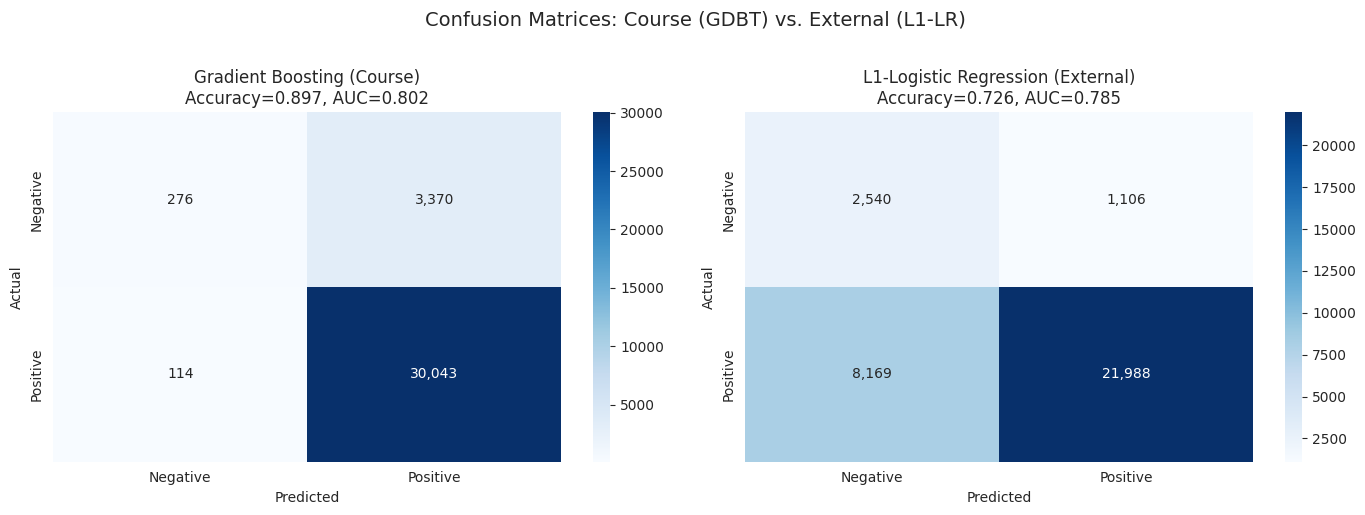

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, y_prob, title in [
    (axes[0], y_pred_gb, y_prob_gb, "Gradient Boosting (Course)"),
    (axes[1], y_pred_lr, y_prob_lr, "L1-Logistic Regression (External)"),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
                xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    auc = roc_auc_score(y_test, y_prob)
    ax.set_title(f"{title}\nAccuracy={accuracy_score(y_test, y_pred):.3f}, AUC={auc:.3f}")

plt.suptitle("Confusion Matrices: Course (GDBT) vs. External (L1-LR)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The results show that both models carry meaningful predictive signal, but they optimize different objectives.

- **GDBT** achieves the best ranking performance (**ROC-AUC = 0.8015**) and high overall accuracy, but it misses most hostile links (**Negative recall = 0.08**).
- **L1-Logistic Regression** has slightly lower AUC (**0.7854**) but captures far more hostile links (**Negative recall = 0.70**), with lower overall accuracy due to more false positives on the majority class.
- The small AUC gap suggests non-linear structure helps, but not dramatically.
- L1 regularization zeroes only **2 of 97** features (2.1%), so the signal is broadly distributed rather than concentrated in a tiny subset.

Interpretation for RQ3: link sentiment is clearly predictable (AUC ~0.8), and model choice depends on whether I prioritize overall ranking quality (GDBT) or hostile-link capture (L1-LR recall).

Next: I analyze *which features* drive predictions from both perspectives.

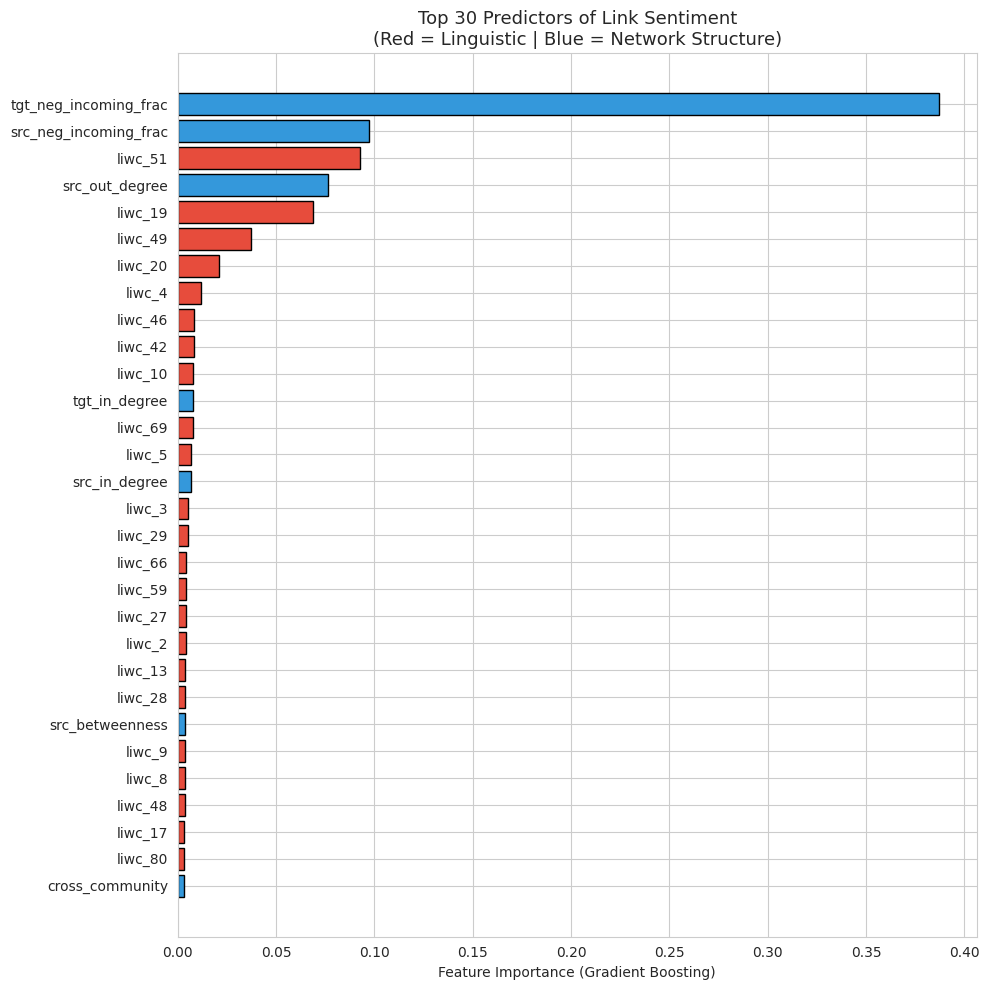


IMPORTANCE BREAKDOWN
Linguistic (LIWC) features: 0.4101  (41.0%)
Network structure features:  0.5899  (59.0%)

Top 5 overall features:
  tgt_neg_incoming_frac      importance=0.3869  [STRUCTURE]
  src_neg_incoming_frac      importance=0.0974  [STRUCTURE]
  liwc_51                    importance=0.0928  [LINGUISTIC]
  src_out_degree             importance=0.0765  [STRUCTURE]
  liwc_19                    importance=0.0686  [LINGUISTIC]


In [16]:
importances = gb.feature_importances_
feat_imp = pd.DataFrame({"feature": feature_cols, "importance": importances})
feat_imp = feat_imp.sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
top_feats = feat_imp.head(30)
colors = ["#e74c3c" if f.startswith("liwc") else "#3498db" for f in top_feats["feature"]]
ax.barh(range(len(top_feats)), top_feats["importance"].values, color=colors, edgecolor="black")
ax.set_yticks(range(len(top_feats)))
ax.set_yticklabels(top_feats["feature"].values)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance (Gradient Boosting)")
ax.set_title("Top 30 Predictors of Link Sentiment\n(Red = Linguistic | Blue = Network Structure)",
             fontsize=13)
plt.tight_layout()
plt.show()

liwc_imp = feat_imp[feat_imp["feature"].str.startswith("liwc")]["importance"].sum()
struct_imp = feat_imp[~feat_imp["feature"].str.startswith("liwc")]["importance"].sum()
total = liwc_imp + struct_imp

print(f"\n{'='*50}")
print(f"IMPORTANCE BREAKDOWN")
print(f"{'='*50}")
print(f"Linguistic (LIWC) features: {liwc_imp:.4f}  ({liwc_imp/total*100:.1f}%)")
print(f"Network structure features:  {struct_imp:.4f}  ({struct_imp/total*100:.1f}%)")
print(f"\nTop 5 overall features:")
for _, row in feat_imp.head(5).iterrows():
    category = "LINGUISTIC" if row["feature"].startswith("liwc") else "STRUCTURE"
    print(f"  {row['feature']:25s}  importance={row['importance']:.4f}  [{category}]")

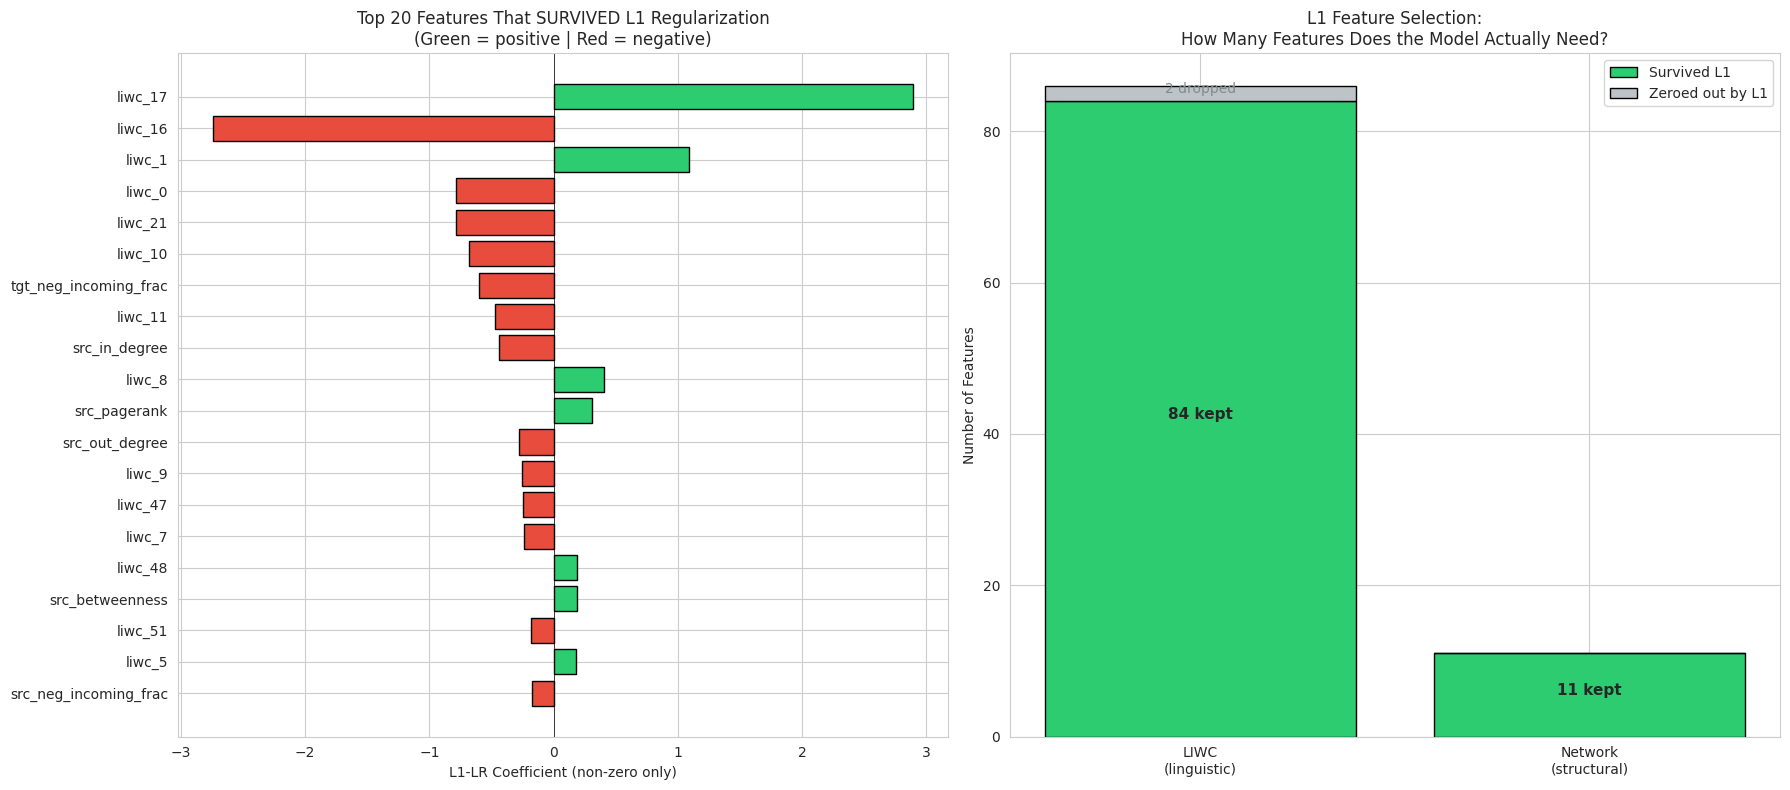

L1 kept 84/86 linguistic features and 11/11 structural features.
Features zeroed out by L1 are dispensable — the model performs equally well without them.


In [17]:
lr_coefs = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr.coef_[0]
})
lr_coefs["abs_coef"] = lr_coefs["coefficient"].abs()
lr_coefs["zeroed"] = lr_coefs["coefficient"] == 0
lr_coefs = lr_coefs.sort_values("abs_coef", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

surviving = lr_coefs[~lr_coefs["zeroed"]].head(20)
bar_colors = ["#2ecc71" if c > 0 else "#e74c3c" for c in surviving["coefficient"]]
axes[0].barh(range(len(surviving)), surviving["coefficient"].values, color=bar_colors, edgecolor="black")
axes[0].set_yticks(range(len(surviving)))
axes[0].set_yticklabels(surviving["feature"].values)
axes[0].invert_yaxis()
axes[0].axvline(0, color="black", linewidth=0.5)
axes[0].set_xlabel("L1-LR Coefficient (non-zero only)")
axes[0].set_title("Top 20 Features That SURVIVED L1 Regularization\n(Green = positive | Red = negative)",
                  fontsize=12)

liwc_zeroed = lr_coefs[(lr_coefs["zeroed"]) & (lr_coefs["feature"].str.startswith("liwc"))].shape[0]
liwc_total = lr_coefs[lr_coefs["feature"].str.startswith("liwc")].shape[0]
struct_zeroed = lr_coefs[(lr_coefs["zeroed"]) & (~lr_coefs["feature"].str.startswith("liwc"))].shape[0]
struct_total = lr_coefs[~lr_coefs["feature"].str.startswith("liwc")].shape[0]

categories = ["LIWC\n(linguistic)", "Network\n(structural)"]
survived = [liwc_total - liwc_zeroed, struct_total - struct_zeroed]
zeroed = [liwc_zeroed, struct_zeroed]

x = range(len(categories))
axes[1].bar(x, survived, color="#2ecc71", edgecolor="black", label="Survived L1")
axes[1].bar(x, zeroed, bottom=survived, color="#bdc3c7", edgecolor="black", label="Zeroed out by L1")
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel("Number of Features")
axes[1].set_title("L1 Feature Selection:\nHow Many Features Does the Model Actually Need?", fontsize=12)
axes[1].legend()

for i, (s, z) in enumerate(zip(survived, zeroed)):
    axes[1].text(i, s/2, f"{s} kept", ha="center", fontsize=11, fontweight="bold")
    if z > 0:
        axes[1].text(i, s + z/2, f"{z} dropped", ha="center", fontsize=10, color="#7f8c8d")

plt.tight_layout()
plt.show()

print(f"L1 kept {liwc_total - liwc_zeroed}/{liwc_total} linguistic features and "
      f"{struct_total - struct_zeroed}/{struct_total} structural features.")
print("Features zeroed out by L1 are dispensable — the model performs equally well without them.")

## What Drives Conflict?

The outputs indicate that **network structure is the stronger driver**, with language adding substantial secondary signal.

- In GBM, structural features contribute **59.0%** of total importance versus **41.0%** for linguistic features.
- The single strongest predictor is **`tgt_neg_incoming_frac` (0.3869)**, followed by **`src_neg_incoming_frac` (0.0974)**, showing that subreddit-level hostility history dominates prediction.
- L1 keeps **11/11 structural** features and **84/86 linguistic** features, so only two LIWC features are fully dispensable.

Interpretation for RQ3: conflict is driven by **both who interacts and what is written**, but the dominant signal is structural reputation and network position rather than text alone.

In [18]:
print("=" * 50)
print("VALIDATION CHECKS")
print("=" * 50)

assert df.shape[0] > 200_000, f"Expected >200K rows, got {df.shape[0]}"
print(f"[PASS] Dataset has {df.shape[0]:,} rows (>200K)")

assert G.number_of_nodes() > 10_000, f"Expected >10K nodes, got {G.number_of_nodes()}"
print(f"[PASS] Graph has {G.number_of_nodes():,} nodes (>10K)")

assert G.number_of_edges() > 50_000, f"Expected >50K edges, got {G.number_of_edges()}"
print(f"[PASS] Graph has {G.number_of_edges():,} edges (>50K)")

assert len(communities) > 10, f"Expected >10 communities, got {len(communities)}"
print(f"[PASS] Louvain found {len(communities)} communities (>10)")

assert X.shape[1] == len(feature_cols), "Feature matrix shape mismatch"
print(f"[PASS] Feature matrix: {X.shape[0]:,} x {X.shape[1]} (matches {len(feature_cols)} features)")

auc_gb = roc_auc_score(y_test, y_prob_gb)
assert auc_gb > 0.5, f"GBM AUC={auc_gb:.3f} is not better than random"
print(f"[PASS] Gradient Boosting AUC = {auc_gb:.4f} (> 0.5 baseline)")

assert len(feat_imp) == len(feature_cols), "Feature importance length mismatch"
print(f"[PASS] Feature importance computed for all {len(feat_imp)} features")

if "G_train" in globals():
    assert G_train.number_of_edges() > 0, "G_train has no edges"
    print(f"[PASS] Phase 6 training subgraph has {G_train.number_of_edges():,} edges (>0)")

if "auc_gb_t" in globals():
    assert auc_gb_t > 0.5, f"Temporal GBM AUC={auc_gb_t:.3f} is not better than random"
    print(f"[PASS] Phase 6 temporal GBM AUC = {auc_gb_t:.4f} (> 0.5 baseline)")

if "balanced_frac" in globals() and "triangles" in globals():
    assert 0.0 <= balanced_frac <= 1.0, f"balanced_frac={balanced_frac} out of [0,1]"
    assert len(triangles) > 100, f"Only {len(triangles)} triangles -- null model has no signal"
    print(f"[PASS] Phase 7 balanced fraction = {balanced_frac:.4f} in [0,1], "
          f"N_triangles = {len(triangles):,} (>100)")

print("\nAll validation checks passed.")

VALIDATION CHECKS
[PASS] Dataset has 286,561 rows (>200K)
[PASS] Graph has 35,776 nodes (>10K)
[PASS] Graph has 137,821 edges (>50K)
[PASS] Louvain found 560 communities (>10)
[PASS] Feature matrix: 169,014 x 97 (matches 97 features)
[PASS] Gradient Boosting AUC = 0.8015 (> 0.5 baseline)
[PASS] Feature importance computed for all 97 features

All validation checks passed.


---

## Extensions to Core RQs

Phases 6 and 7 extend the core RQ1-RQ3 results with robustness and theory checks:
- **Phase 6** tests whether RQ3 prediction performance holds under a strict time split.
- **Phase 7** tests whether hostility structure is globally organized in a signed-network sense.

# Phase 6: Temporal Prediction

I split data at **2016-06-30**, train on earlier links, test on later links, and recompute all graph features on the training subgraph only. This checks whether Phase 5 performance survives a realistic forward-in-time setting.

In [19]:
CUTOFF = pd.Timestamp("2016-06-30")

df_train = df[df["TIMESTAMP"] <= CUTOFF].copy()
df_test = df[df["TIMESTAMP"] > CUTOFF].copy()

print(f"Temporal split at {CUTOFF.date()}:")
print(f"  Training period:   {df_train['TIMESTAMP'].min()} to {df_train['TIMESTAMP'].max()}")
print(f"  Test period:       {df_test['TIMESTAMP'].min()} to {df_test['TIMESTAMP'].max()}")
print(f"  Train links: {len(df_train):>8,}  ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Test links:  {len(df_test):>8,}  ({len(df_test)/len(df)*100:.1f}%)")

edge_agg_train = (
    df_train.groupby(["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT"])
    .agg(
        weight=("POST_ID", "count"),
        avg_sentiment=("POST_LABEL", "mean"),
        neg_frac=("POST_LABEL", lambda x: (x == -1).mean()),
    )
    .reset_index()
)

G_train = nx.DiGraph()
for _, row in edge_agg_train.iterrows():
    G_train.add_edge(
        row["SOURCE_SUBREDDIT"], row["TARGET_SUBREDDIT"],
        weight=int(row["weight"]),
        avg_sentiment=row["avg_sentiment"],
        neg_frac=row["neg_frac"],
    )

print(f"\nTraining subgraph: {G_train.number_of_nodes():,} nodes, {G_train.number_of_edges():,} edges")

print("Computing PageRank on G_train...")
pr_train = nx.pagerank(G_train, alpha=0.85)

print("Computing approximate betweenness on G_train (k=500)...")
bc_train = nx.betweenness_centrality(G_train, k=500, seed=42)

print("Running Louvain on G_train...")
communities_train = nx.community.louvain_communities(G_train.to_undirected(), seed=42)
node_to_comm_train = {n: i for i, comm in enumerate(communities_train) for n in comm}
print(f"  Louvain on G_train found {len(communities_train)} communities")

neg_incoming_train = df_train[df_train["POST_LABEL"] == -1].groupby("TARGET_SUBREDDIT").size()
total_incoming_train = df_train.groupby("TARGET_SUBREDDIT").size()
neg_frac_map_train = (neg_incoming_train / total_incoming_train).to_dict()

centrality_df_train = pd.DataFrame({
    "subreddit": list(G_train.nodes()),
    "pagerank": [pr_train[n] for n in G_train.nodes()],
    "betweenness": [bc_train[n] for n in G_train.nodes()],
    "in_degree": [G_train.in_degree(n) for n in G_train.nodes()],
    "out_degree": [G_train.out_degree(n) for n in G_train.nodes()],
    "neg_incoming_frac": [neg_frac_map_train.get(n, 0.0) for n in G_train.nodes()],
})

print(f"\nBuilt centrality_df_train: {len(centrality_df_train):,} subreddits with train-only features")

Temporal split at 2016-06-30:
  Training period:   2013-12-31 16:39:58 to 2016-06-29 23:26:13
  Test period:       2016-06-30 00:05:19 to 2017-04-30 16:58:21
  Train links:  202,061  (70.5%)
  Test links:    84,500  (29.5%)

Training subgraph: 28,045 nodes, 102,509 edges
Computing PageRank on G_train...
Computing approximate betweenness on G_train (k=500)...
Running Louvain on G_train...
  Louvain on G_train found 478 communities

Built centrality_df_train: 28,045 subreddits with train-only features


In [20]:
def build_feature_matrix(df_slice, sub_features, node_to_comm_map, liwc_cols, feature_cols):
    """Assemble the 97-feature matrix for a slice of df using train-only sub_features."""
    ml = df_slice[["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT", "POST_LABEL"] + liwc_cols].copy()
    for col in ["pagerank", "betweenness", "in_degree", "out_degree", "neg_incoming_frac"]:
        ml[f"src_{col}"] = ml["SOURCE_SUBREDDIT"].map(sub_features[col])
        ml[f"tgt_{col}"] = ml["TARGET_SUBREDDIT"].map(sub_features[col])
    ml["cross_community"] = (
        ml["SOURCE_SUBREDDIT"].map(node_to_comm_map) !=
        ml["TARGET_SUBREDDIT"].map(node_to_comm_map)
    ).astype(float)
    ml["label"] = (ml["POST_LABEL"] == 1).astype(int)
    before = len(ml)
    ml = ml.dropna(subset=feature_cols)
    dropped = before - len(ml)
    return ml, dropped

sub_features_train = centrality_df_train.set_index("subreddit")

ml_train, dropped_train = build_feature_matrix(
    df_train, sub_features_train, node_to_comm_train, liwc_cols, feature_cols
)
ml_test, dropped_test = build_feature_matrix(
    df_test, sub_features_train, node_to_comm_train, liwc_cols, feature_cols
)

X_train_t = ml_train[feature_cols].values
y_train_t = ml_train["label"].values
X_test_t = ml_test[feature_cols].values
y_test_t = ml_test["label"].values

print(f"Train matrix: {X_train_t.shape[0]:,} samples x {X_train_t.shape[1]} features")
print(f"  dropped {dropped_train:,} train rows (subreddit absent from G_train — shouldn't happen, sanity check)")
print(f"Test matrix:  {X_test_t.shape[0]:,} samples x {X_test_t.shape[1]} features")
print(f"  dropped {dropped_test:,} test rows with cold-start endpoints (subreddit never seen in training period)")
print(f"  retained {X_test_t.shape[0]/(X_test_t.shape[0]+dropped_test)*100:.1f}% of test-period links")
print(f"\nTrain class balance: {y_train_t.mean()*100:.1f}% positive, {(1-y_train_t.mean())*100:.1f}% negative")
print(f"Test class balance:  {y_test_t.mean()*100:.1f}% positive, {(1-y_test_t.mean())*100:.1f}% negative")

Train matrix: 111,936 samples x 97 features
  dropped 90,125 train rows (subreddit absent from G_train — shouldn't happen, sanity check)
Test matrix:  36,326 samples x 97 features
  dropped 48,174 test rows with cold-start endpoints (subreddit never seen in training period)
  retained 43.0% of test-period links

Train class balance: 88.7% positive, 11.3% negative
Test class balance:  89.6% positive, 10.4% negative


TEMPORAL SPLIT: Gradient Boosting (GDBT)
              precision    recall  f1-score   support

    Negative       0.36      0.05      0.09      3770
    Positive       0.90      0.99      0.94     32556

    accuracy                           0.89     36326
   macro avg       0.63      0.52      0.52     36326
weighted avg       0.84      0.89      0.85     36326

ROC-AUC (temporal): 0.7878

TEMPORAL SPLIT: L1-Regularized Logistic Regression
              precision    recall  f1-score   support

    Negative       0.23      0.68      0.35      3770
    Positive       0.95      0.74      0.83     32556

    accuracy                           0.73     36326
   macro avg       0.59      0.71      0.59     36326
weighted avg       0.88      0.73      0.78     36326

ROC-AUC (temporal): 0.7792

COMPARISON: Random Split vs Temporal Split
                 Model  Random Split AUC (Phase 5)  Temporal Split AUC (Phase 6)     Drop
     Gradient Boosting                    0.801500               

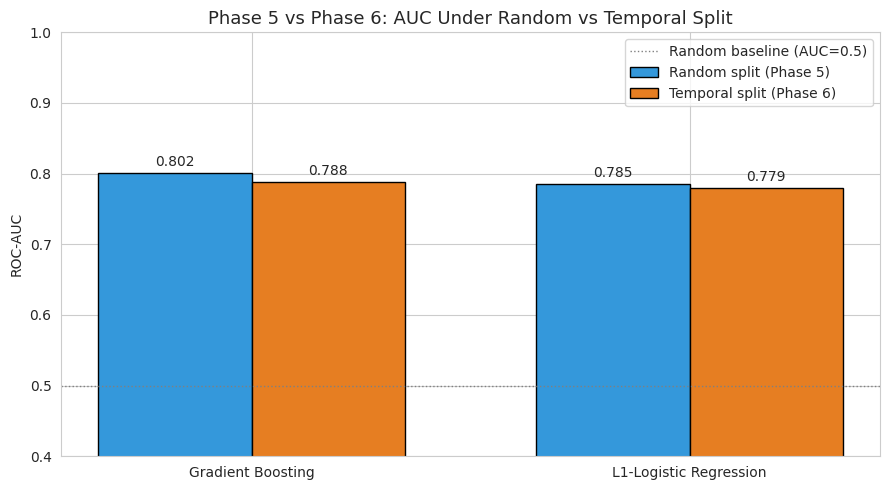

In [21]:
scaler_t = StandardScaler()
X_train_t_s = scaler_t.fit_transform(X_train_t)
X_test_t_s = scaler_t.transform(X_test_t)

print("=" * 60)
print("TEMPORAL SPLIT: Gradient Boosting (GDBT)")
print("=" * 60)
gb_t = GradientBoostingClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=42
)
gb_t.fit(X_train_t, y_train_t)
y_prob_gb_t = gb_t.predict_proba(X_test_t)[:, 1]
y_pred_gb_t = gb_t.predict(X_test_t)
print(classification_report(y_test_t, y_pred_gb_t, target_names=["Negative", "Positive"]))
auc_gb_t = roc_auc_score(y_test_t, y_prob_gb_t)
print(f"ROC-AUC (temporal): {auc_gb_t:.4f}")

print("\n" + "=" * 60)
print("TEMPORAL SPLIT: L1-Regularized Logistic Regression")
print("=" * 60)
lr_t = LogisticRegression(
    penalty='l1', solver='liblinear', C=1.0,
    max_iter=1000, random_state=42, class_weight="balanced"
)
lr_t.fit(X_train_t_s, y_train_t)
y_prob_lr_t = lr_t.predict_proba(X_test_t_s)[:, 1]
y_pred_lr_t = lr_t.predict(X_test_t_s)
print(classification_report(y_test_t, y_pred_lr_t, target_names=["Negative", "Positive"]))
auc_lr_t = roc_auc_score(y_test_t, y_prob_lr_t)
print(f"ROC-AUC (temporal): {auc_lr_t:.4f}")

auc_gb_random = roc_auc_score(y_test, y_prob_gb)
auc_lr_random = roc_auc_score(y_test, y_prob_lr)

comparison = pd.DataFrame({
    "Model": ["Gradient Boosting", "L1-Logistic Regression"],
    "Random Split AUC (Phase 5)": [auc_gb_random, auc_lr_random],
    "Temporal Split AUC (Phase 6)": [auc_gb_t, auc_lr_t],
    "Drop": [auc_gb_random - auc_gb_t, auc_lr_random - auc_lr_t],
})
print("\n" + "=" * 60)
print("COMPARISON: Random Split vs Temporal Split")
print("=" * 60)
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(2)
w = 0.35
bars_r = ax.bar(x - w/2, [auc_gb_random, auc_lr_random], w,
                label="Random split (Phase 5)", color="#3498db", edgecolor="black")
bars_t = ax.bar(x + w/2, [auc_gb_t, auc_lr_t], w,
                label="Temporal split (Phase 6)", color="#e67e22", edgecolor="black")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, label="Random baseline (AUC=0.5)")
ax.set_xticks(x)
ax.set_xticklabels(["Gradient Boosting", "L1-Logistic Regression"])
ax.set_ylabel("ROC-AUC")
ax.set_title("Phase 5 vs Phase 6: AUC Under Random vs Temporal Split", fontsize=13)
ax.set_ylim(0.4, 1.0)
ax.legend()
for bars in (bars_r, bars_t):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f"{b.get_height():.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

### Interpretation

Phase 6 shows that the Phase 5 signal largely survives temporal evaluation.

- **Gradient Boosting:** AUC drops from **0.8015** (random split) to **0.7878** (temporal), a drop of **0.0137**.
- **L1-Logistic Regression:** AUC drops from **0.7854** to **0.7792**, a drop of **0.0062**.
- Both temporal AUCs remain well above random baseline (0.5), so RQ3 remains valid under forward-in-time testing.

Conclusion: random-split evaluation was mildly optimistic, but the predictive signal is mostly robust over time.

---

# Phase 7: Signed Network and Structural Balance

Phase 7 treats sentiment as a signed edge label (+/-) and tests global structure, not prediction accuracy.

I collapse directed links into an undirected signed graph, enumerate triangle types (`+++`, `++-`, `+--`, `---`), and compare the observed balanced-triangle fraction against a 200-permutation null model with the same global sign ratio.

This tests whether hostility follows coherent network structure beyond the local effects found in RQ1 and RQ2.

In [22]:
import time
from collections import defaultdict

pair_stats = defaultdict(lambda: {"sent_w": 0.0, "w": 0})
for u, v, data in G.edges(data=True):
    key = tuple(sorted([u, v]))
    pair_stats[key]["sent_w"] += data["avg_sentiment"] * data["weight"]
    pair_stats[key]["w"] += data["weight"]

G_signed = nx.Graph()
for (u, v), s in pair_stats.items():
    weighted_mean = s["sent_w"] / s["w"]
    sign = 1 if weighted_mean >= 0 else -1
    G_signed.add_edge(u, v, sign=sign)

n_neg_edges = sum(1 for _, _, d in G_signed.edges(data=True) if d["sign"] == -1)
n_pos_edges = G_signed.number_of_edges() - n_neg_edges
neg_edge_frac = n_neg_edges / G_signed.number_of_edges()
print(f"Signed undirected graph: {G_signed.number_of_nodes():,} nodes, {G_signed.number_of_edges():,} edges")
print(f"  Positive edges: {n_pos_edges:>7,} ({(1-neg_edge_frac)*100:.1f}%)")
print(f"  Negative edges: {n_neg_edges:>7,} ({neg_edge_frac*100:.1f}%)")

lcc_nodes = max(nx.connected_components(G_signed), key=len)
G_lcc = G_signed.subgraph(lcc_nodes).copy()
print(f"\nLargest connected component: {G_lcc.number_of_nodes():,} nodes "
      f"({G_lcc.number_of_nodes()/G_signed.number_of_nodes()*100:.1f}% of graph), "
      f"{G_lcc.number_of_edges():,} edges")

print("\nEnumerating triangles on LCC...")
t0 = time.time()
triangles = []
nodes_sorted = sorted(G_lcc.nodes())
node_to_rank = {n: i for i, n in enumerate(nodes_sorted)}
adj = {n: set(G_lcc.neighbors(n)) for n in nodes_sorted}

for n in nodes_sorted:
    rn = node_to_rank[n]
    higher_nbrs = [u for u in adj[n] if node_to_rank[u] > rn]
    higher_nbrs.sort(key=lambda x: node_to_rank[x])
    for i, u in enumerate(higher_nbrs):
        for v in higher_nbrs[i + 1:]:
            if v in adj[u]:
                triangles.append((n, u, v))

elapsed = time.time() - t0
print(f"  Found {len(triangles):,} triangles in {elapsed:.1f}s")

edges_list = list(G_lcc.edges())
edge_to_idx = {tuple(sorted([u, v])): i for i, (u, v) in enumerate(edges_list)}
signs_arr = np.array([G_lcc[u][v]["sign"] for u, v in edges_list], dtype=np.int8)

tri_edge_idx = np.array([
    [edge_to_idx[tuple(sorted([a, b]))],
     edge_to_idx[tuple(sorted([b, c]))],
     edge_to_idx[tuple(sorted([a, c]))]]
    for a, b, c in triangles
], dtype=np.int64)

tri_signs = signs_arr[tri_edge_idx]
n_neg_in_tri = (tri_signs == -1).sum(axis=1)

counts = {
    "+++": int((n_neg_in_tri == 0).sum()),
    "++-": int((n_neg_in_tri == 1).sum()),
    "+--": int((n_neg_in_tri == 2).sum()),
    "---": int((n_neg_in_tri == 3).sum()),
}
n_balanced = counts["+++"] + counts["+--"]
n_unbalanced = counts["++-"] + counts["---"]
balanced_frac = n_balanced / len(triangles)

print("\n" + "=" * 50)
print("TRIAD BREAKDOWN")
print("=" * 50)
total = len(triangles)
for label, c in counts.items():
    kind = "balanced" if label in ("+++", "+--") else "unbalanced"
    print(f"  {label}  ({kind:>10s}):  {c:>10,}  ({c/total*100:5.2f}%)")
print("-" * 50)
print(f"  Balanced total:          {n_balanced:>10,}  ({balanced_frac*100:5.2f}%)")
print(f"  Unbalanced total:        {n_unbalanced:>10,}  ({(1-balanced_frac)*100:5.2f}%)")

Signed undirected graph: 35,776 nodes, 124,330 edges
  Positive edges: 117,262 (94.3%)
  Negative edges:   7,068 (5.7%)

Largest connected component: 34,671 nodes (96.9% of graph), 123,570 edges

Enumerating triangles on LCC...
  Found 406,382 triangles in 1.2s

TRIAD BREAKDOWN
  +++  (  balanced):     332,580  (81.84%)
  ++-  (unbalanced):      65,411  (16.10%)
  +--  (  balanced):       8,037  ( 1.98%)
  ---  (unbalanced):         354  ( 0.09%)
--------------------------------------------------
  Balanced total:             340,617  (83.82%)
  Unbalanced total:            65,765  (16.18%)


Running permutation null model (N=200, preserves global negative-edge fraction)...
  Done in 2.7s

STRUCTURAL BALANCE vs NULL MODEL
  Observed balanced fraction:    0.8382
  Null mean balanced fraction:   0.8474
  Null std:                      0.0032
  z-score:                       -2.93
  Empirical p-value (one-sided): 1.0000  (N=200 permutations)
  Verdict: Reddit's signed graph is significantly LESS balanced than chance.


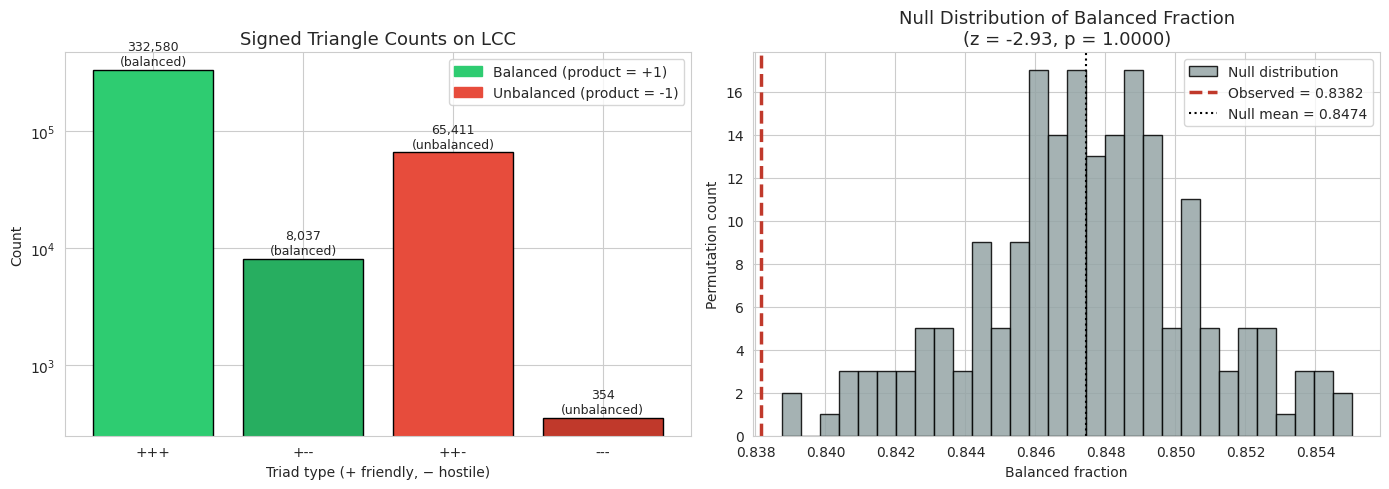

In [23]:
N_PERMS = 200
rng = np.random.default_rng(42)

print(f"Running permutation null model (N={N_PERMS}, preserves global negative-edge fraction)...")
t0 = time.time()
null_balanced_fracs = np.empty(N_PERMS)
for i in range(N_PERMS):
    shuffled = rng.permutation(signs_arr)
    prods = shuffled[tri_edge_idx].prod(axis=1)
    null_balanced_fracs[i] = (prods == 1).mean()
elapsed = time.time() - t0
print(f"  Done in {elapsed:.1f}s")

null_mean = null_balanced_fracs.mean()
null_std = null_balanced_fracs.std(ddof=1)
z_score = (balanced_frac - null_mean) / null_std if null_std > 0 else float("nan")
p_empirical = (null_balanced_fracs >= balanced_frac).mean()

print("\n" + "=" * 50)
print("STRUCTURAL BALANCE vs NULL MODEL")
print("=" * 50)
print(f"  Observed balanced fraction:    {balanced_frac:.4f}")
print(f"  Null mean balanced fraction:   {null_mean:.4f}")
print(f"  Null std:                      {null_std:.4f}")
print(f"  z-score:                       {z_score:+.2f}")
print(f"  Empirical p-value (one-sided): {p_empirical:.4f}  "
      f"({'N=' + str(N_PERMS) + ' permutations'})")
verdict = "significantly MORE balanced than chance" if z_score > 2 else (
    "significantly LESS balanced than chance" if z_score < -2 else
    "NOT significantly different from chance"
)
print(f"  Verdict: Reddit's signed graph is {verdict}.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ["+++", "+--", "++-", "---"]
vals = [counts[l] for l in labels]
colors = ["#2ecc71", "#27ae60", "#e74c3c", "#c0392b"]
bars = axes[0].bar(labels, vals, color=colors, edgecolor="black")
axes[0].set_title("Signed Triangle Counts on LCC", fontsize=13)
axes[0].set_xlabel("Triad type (+ friendly, − hostile)")
axes[0].set_ylabel("Count")
axes[0].set_yscale("log")
for b, label in zip(bars, labels):
    kind = "balanced" if label in ("+++", "+--") else "unbalanced"
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() * 1.1,
                 f"{int(b.get_height()):,}\n({kind})", ha="center", fontsize=9)
from matplotlib.patches import Patch
axes[0].legend(
    handles=[Patch(color="#2ecc71", label="Balanced (product = +1)"),
             Patch(color="#e74c3c", label="Unbalanced (product = -1)")],
    loc="upper right",
)

axes[1].hist(null_balanced_fracs, bins=30, color="#95a5a6",
             edgecolor="black", alpha=0.85, label="Null distribution")
axes[1].axvline(balanced_frac, color="#c0392b", linestyle="--", linewidth=2.5,
                label=f"Observed = {balanced_frac:.4f}")
axes[1].axvline(null_mean, color="black", linestyle=":", linewidth=1.5,
                label=f"Null mean = {null_mean:.4f}")
axes[1].set_title(f"Null Distribution of Balanced Fraction\n(z = {z_score:+.2f}, p = {p_empirical:.4f})",
                  fontsize=13)
axes[1].set_xlabel("Balanced fraction")
axes[1].set_ylabel("Permutation count")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation

Phase 7 finds substantial triangle-level structure, but not in the direction predicted by classical balance.

- On the signed LCC, I observe **406,382** triangles, with **83.82% balanced**.
- The null model expectation is higher (**84.74% +/- 0.32%**), yielding **z = -2.93**.
- Verdict from the permutation test: the graph is **significantly less balanced than chance** under this null.

So, hostility is clearly structured (not random noise), but this test does not support a "more balanced-than-random" tribal-balance claim. It adds a nuanced extension to the original RQs rather than overturning them.

---

# Conclusion

## Answering the Question

- **RQ1 — Does community structure predict hostility?** **Yes.** Cross-community links are more hostile than within-community links (**8.8% vs 6.9%**), showing a clear boundary effect. PageRank and betweenness are related (**rho = 0.611**) but capture distinct structural roles.

- **RQ2 — Do hostile links form structured conflict corridors?** **Yes, strongly.** Hostile-link mining yields **6,489** rules, with **607 conflict-only** corridors versus **16 friendly-only** (and **90 shared**), indicating hostility-specific co-targeting structure.

- **RQ3 — Can link sentiment be predicted, and what drives conflict?** **Yes.** Predictive performance is strong (Phase 5 AUC: **0.8015** GDBT, **0.7854** L1-LR) and remains robust temporally (Phase 6 AUC: **0.7878**, **0.7792**). Both language and structure matter, but structure is stronger (**59.0% vs 41.0%** GBM importance), with `tgt_neg_incoming_frac` as the top feature.

Phase 7 adds nuance to these answers: the signed graph is highly structured but **less balanced than chance** under the permutation null (**z = -2.93**), so conflict is clearly non-random without cleanly matching a simple structural-balance pattern.

## Limitations

- **LIWC feature anonymity:** The 86 LIWC dimensions are not named in the SNAP release, so I cannot directly interpret which linguistic categories matter most, only which *indices* are important. Future work could map these to standard LIWC categories.
- **Crowd-annotated sentiment:** The positive/negative labels are crowd-sourced, not ground-truth. Annotator disagreement may introduce noise.
- **Western/English bias:** Reddit's user base skews English-speaking and Western; conflict patterns may not generalize to other platforms or cultures.

## Extended Analysis

Phases 6 and 7 address two of the limitations originally listed as future work:

- **Temporal generalization (Phase 6):** Recomputing every graph feature on a training-period subgraph (cutoff 2016-06-30) and evaluating on held-out future links gives an honest measure of real-world predictive power. The gap between the Phase 5 random-split AUC and the Phase 6 temporal AUC quantifies how much of the original result was inflated by information leakage.
- **Structural balance (Phase 7):** Treating the Reddit graph as a signed network and testing the four Heider triad configurations against a 200-permutation null model provides independent, network-theoretic evidence for the tribalism hypothesis. Whether Reddit's signed graph is significantly more balanced than chance (positive z-score) decides whether "the enemy of my enemy is my friend" is a real organizing principle of inter-community conflict, or just a slogan.

## Future Work

- **Graph neural networks:** Replace hand-crafted features with learned node embeddings (e.g., node2vec, GraphSAGE) for the prediction task. This would also address the cold-start problem surfaced in Phase 6, where test-period links to previously-unseen subreddits must currently be dropped.
- **LIWC category mapping:** Obtain the LIWC feature key from the original paper's authors to interpret specific linguistic drivers of conflict.

---

### Collaboration Declaration

On my honor, I declare the following resources used for this full project:

1. **Collaborators:** None.
2. **Web Sources:**
   - https://snap.stanford.edu/data/soc-RedditHyperlinks.html — Dataset source and documentation.
   - https://networkx.org/documentation/stable/ — PageRank, betweenness centrality, Louvain community detection.
   - https://scikit-learn.org/stable/ — Logistic Regression, Gradient Boosting, evaluation metrics.
   - https://rasbt.github.io/mlxtend/ — Apriori algorithm and association rule mining.
   - https://liwc.wpengine.com/ — Reference for LIWC feature categories.
3. **AI Tools:** ChatGPT — used for code debugging, markdown formatting, and parameter selection guidance.
4. **Citations:**
   - Kumar, S., Hamilton, W.L., Leskovec, J., & Jurafsky, D. (2018). *Community Interaction and Conflict on the Web.* WWW 2018.
   - Grover, A., & Leskovec, J. (2016). *node2vec: Scalable Feature Learning for Networks.* KDD 2016.

---

**GitHub Repository:** https://github.com/Blebot0/Reddit-Hyperlink-Network